# Histogram task S exp

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os

In [2]:
run_id = "20251201_2051" # pour les grpahs 
# run_id = ""


run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

## 1. experiment config

In [3]:
# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251201_2051/config.csv


,D,L,T,d_mlp_list,alpha,rho,beta,lambda,samples,max_iter,...,p_fine_tune,device,logger,run_dir,run_index,seed,batch_size,R,N,MLP_dim
0,100,15,30,"[5, 10, 30, 50]",0.807143,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_1_2739091 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,1,42,64,100,80,50
1,100,15,30,"[5, 10, 30, 50]",0.100000,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_0_2739090 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,0,42,64,100,10,50
2,100,15,30,"[5, 10, 30, 50]",1.514286,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_2_2739092 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,2,42,64,100,151,50
3,100,15,30,"[5, 10, 30, 50]",2.221429,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_3_2739093 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,3,42,64,100,222,50
4,100,15,30,"[5, 10, 30, 50]",3.635714,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_5_2739095 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,5,42,64,100,363,50
5,100,15,30,"[5, 10, 30, 50]",4.342857,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_6_2739096 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,6,42,64,100,434,50
6,100,15,30,"[5, 10, 30, 50]",2.928571,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_4_2739094 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,4,42,64,100,292,50
7,100,15,30,"[5, 10, 30, 50]",5.050000,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_7_2739097 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,7,42,64,100,505,50
8,100,15,30,"[5, 10, 30, 50]",5.757143,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_8_2739098 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,8,42,64,100,575,50
9,100,15,30,"[5, 10, 30, 50]",7.171429,1.0,1.0,0.0001,20,5000,...,0.15,cuda,<Logger logger_10_2739100 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,10,42,64,100,717,50


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (60 rows) from ../results/run_20251201_2051/summary.csv


<>:163: SyntaxWarning: invalid escape sequence '\k'
<>:190: SyntaxWarning: invalid escape sequence '\k'
<>:219: SyntaxWarning: invalid escape sequence '\D'
<>:163: SyntaxWarning: invalid escape sequence '\k'
<>:190: SyntaxWarning: invalid escape sequence '\k'
<>:219: SyntaxWarning: invalid escape sequence '\D'
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_3199/2389838409.py:163: SyntaxWarning: invalid escape sequence '\k'
  plt.ylabel("$\kappa_0$ (before fine-tune)")
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_3199/2389838409.py:190: SyntaxWarning: invalid escape sequence '\k'
  plt.ylabel("$\kappa_0$ (after fine-tune)")
/var/folders/ml/mckm5tb169sckcm9zfghvmm80000gn/T/ipykernel_3199/2389838409.py:219: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta \kappa_0$")


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.807143,5,1.0,0.000091,0.000004,0.000139,0.000016,0.000155,0.000024,0.088472,0.038334,0.146292,0.050567,0.480940,0.088287,99.30,1.031095,98.05,2.645254
1,0.807143,10,1.0,0.000091,0.000003,0.000101,0.000023,0.000123,0.000011,0.088889,0.025886,0.234550,0.051294,0.597160,0.056427,99.35,0.875094,99.60,0.502625
2,0.807143,30,1.0,0.000082,0.000004,0.000040,0.000030,0.000070,0.000008,0.179583,0.040986,0.354131,0.055964,0.851907,0.049187,99.60,0.502625,99.85,0.366348
3,0.807143,50,1.0,0.000082,0.000004,0.000024,0.000031,0.000055,0.000007,0.184167,0.035824,0.446964,0.073917,0.914332,0.043813,99.30,0.732695,99.80,0.410391
4,0.100000,5,1.0,0.000089,0.000008,0.000010,0.000018,0.000029,0.000027,0.109167,0.075408,0.604700,0.199878,0.967167,0.086955,99.05,0.825578,96.75,3.242400


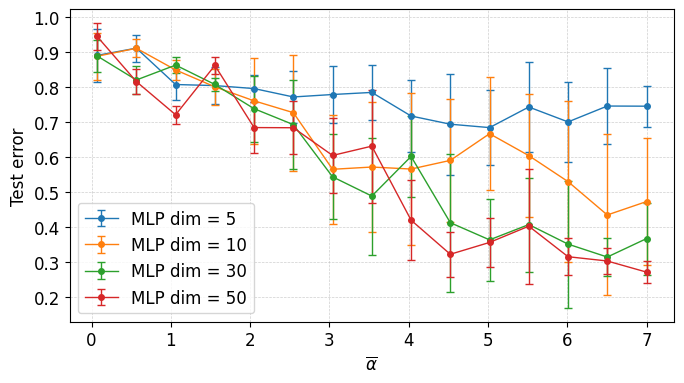

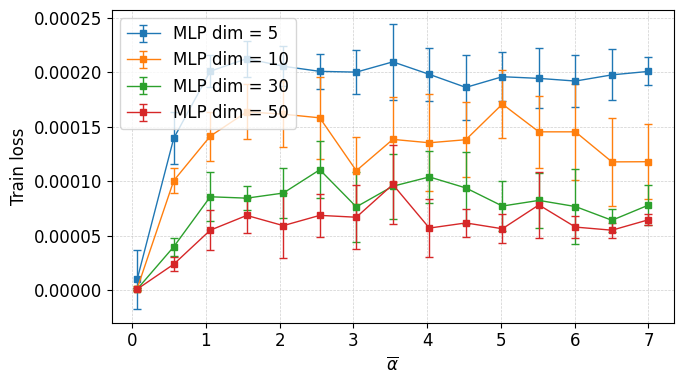

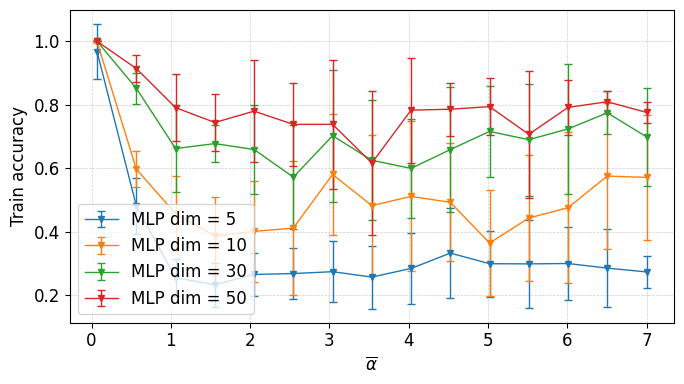

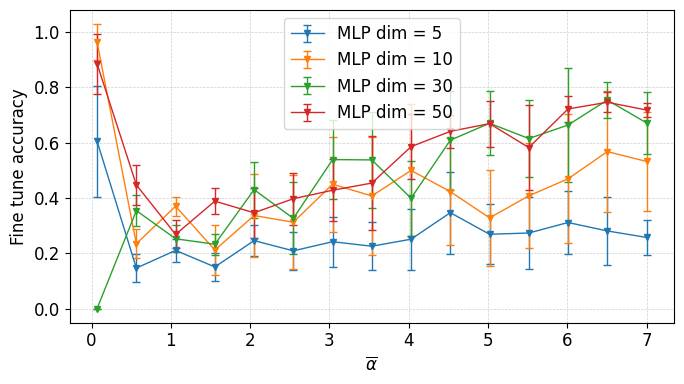

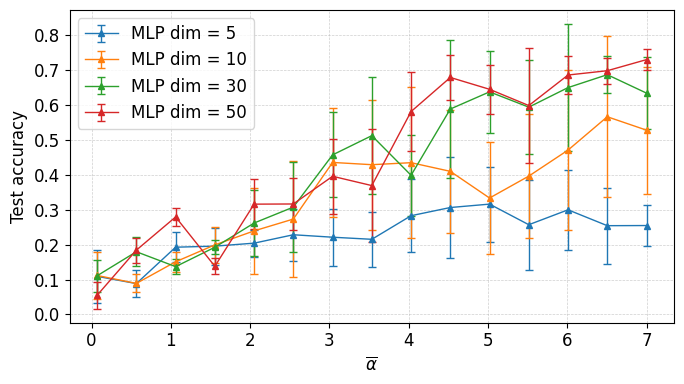

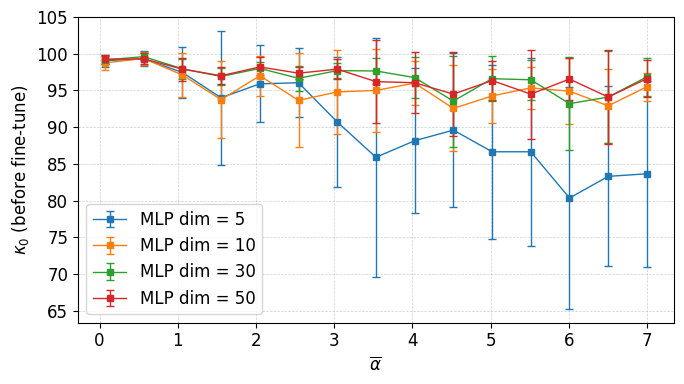

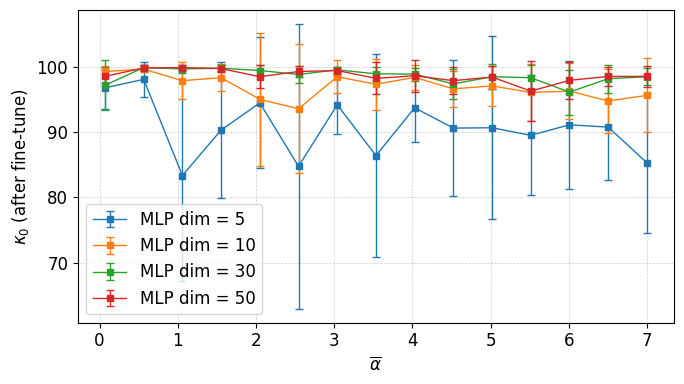

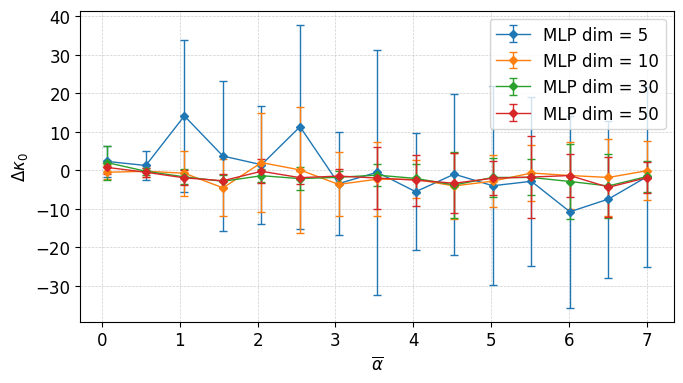

In [4]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

facteur = 0.7 # alpha que tu train 
test_error_factor = config.D[0]**2 # pour contrer le mauvais enregistrement 

plt.rcParams.update({'font.size': 12}) 

# --- Plot Label Error vs alpha with error bars (grouped by MLP_dim) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"] * facteur,
        subset["label_err_mean"] * test_error_factor,
        yerr=subset.get("label_err_std", 0) * test_error_factor,
        marker='o',
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test error")
# plt.title(f"Label Error vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"label_error_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by MLP_dim) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"] * facteur,
        subset["train_data_mean"],
        yerr=subset.get("train_total_std", 0),
        marker='s',           
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Train loss")
# plt.title(f"Train Data vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"train_data_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"] * facteur,
        subset["acc_train_mean"],
        yerr=subset.get("acc_train_std", 0),
        marker='v',          # downward triangle to differ from test accuracy (^)
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Train accuracy")
# plt.title(f"Train Accuracy vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"train_accuracy_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"] * facteur,
        subset["acc_fine_tune_mean"],
        yerr=subset.get("acc_fine_tune_std", 0),
        marker='v',          # downward triangle to differ from test accuracy (^)
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Fine tune accuracy")
# plt.title(f"Fine Tune Accuracy vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"fine_tune_accuracy_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"] * facteur,
        subset["acc_test_mean"],
        yerr=subset.get("acc_test_std", 0),
        marker='^',
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test accuracy")
# plt.title(f"Test Accuracy vs α")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"test_accuracy_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- rank before fine tune---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"] * facteur,
        subset["rank_before_mean"],
        yerr=subset.get("rank_before_std", 0),
        marker='s',          # carré = clair, académique, lisible
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("$\kappa_0$ (before fine-tune)")
# plt.title("Rank of $W_0$ (before fine-tune)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"rank_before_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- rank after fine tune ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(
        subset["alpha"] * facteur,
        subset["rank_after_mean"],
        yerr=subset.get("rank_after_std", 0),
        marker='s',          # carré pour cohérence avec rank_before
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("$\kappa_0$ (after fine-tune)")
# plt.title("Rank of $W_0$ (after fine-tune)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"rank_after_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# --- diff rank ---
plt.figure(figsize=(7, 4))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    diff_mean = subset["rank_before_mean"] - subset["rank_after_mean"]
    diff_std  = subset.get("rank_before_std", 0) + subset.get("rank_after_std", 0)
    plt.errorbar(
        subset["alpha"] * facteur,
        diff_mean,
        yerr=diff_std,
        marker='D',         
        markersize=4,
        linewidth=1,
        capsize=3,
        label=f"MLP dim = {MLP_dim}"
    )
plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("$\Delta \kappa_0$")
# plt.title("Rank Difference of $W_0$ (before – after fine-tune)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(plot_path, f"rank_diff_vs_alpha_run{run_id}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 3. Results visualisation

Found 15 heavy_data files.

--- File: ../results/run_20251201_2051/heavy_data_0.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = -0.000911


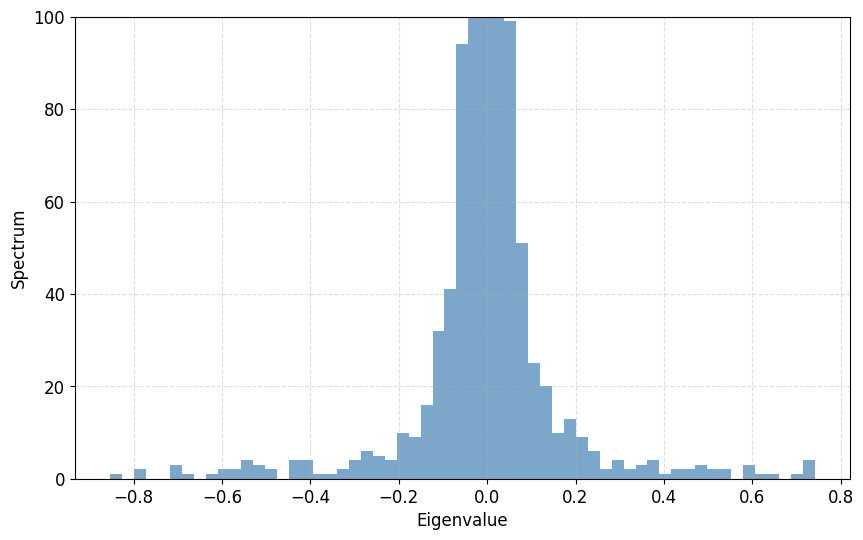

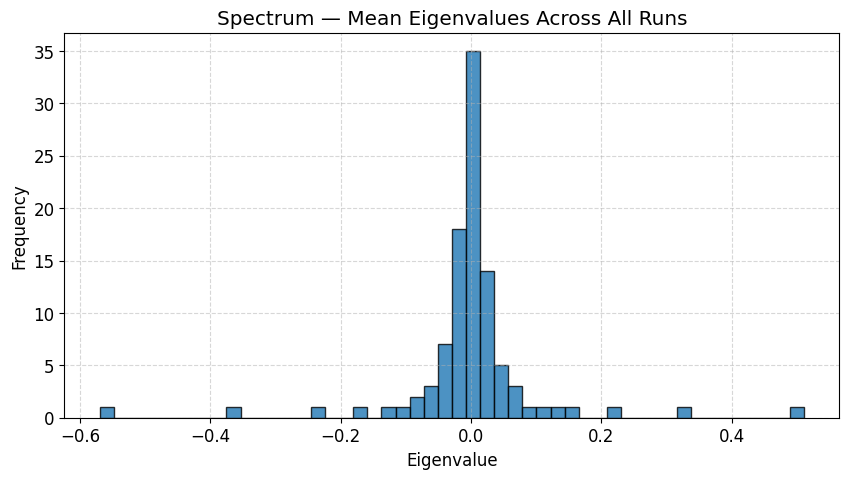

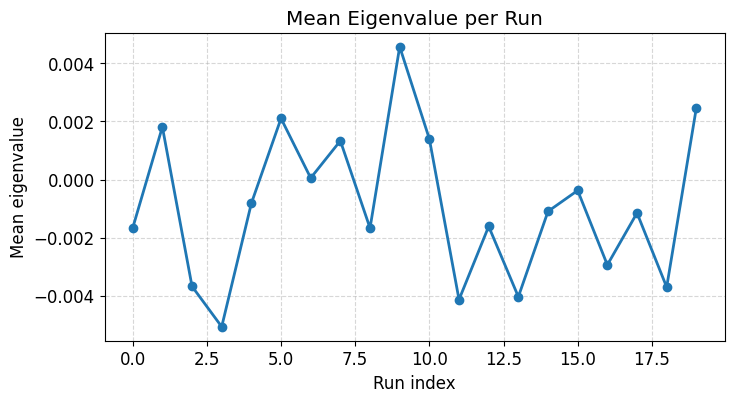

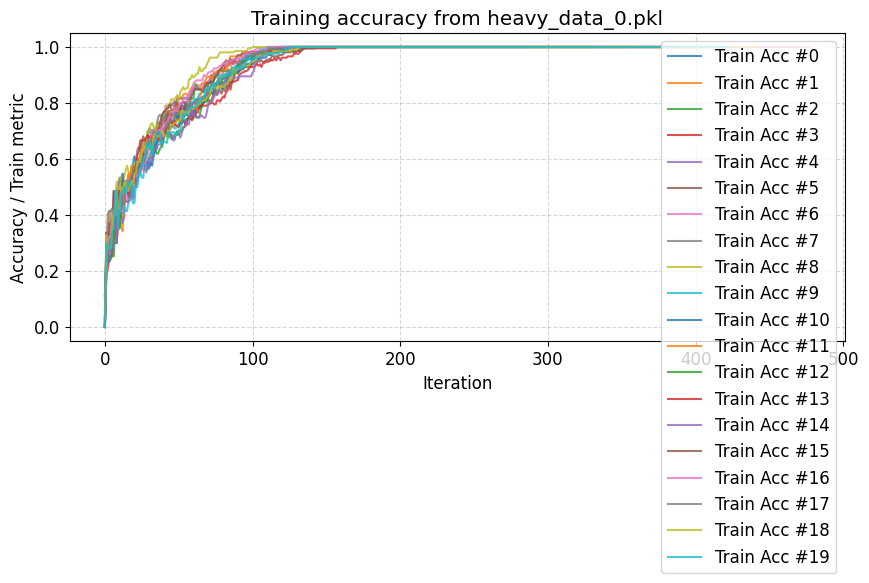

--- File: ../results/run_20251201_2051/heavy_data_1.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = -0.003051


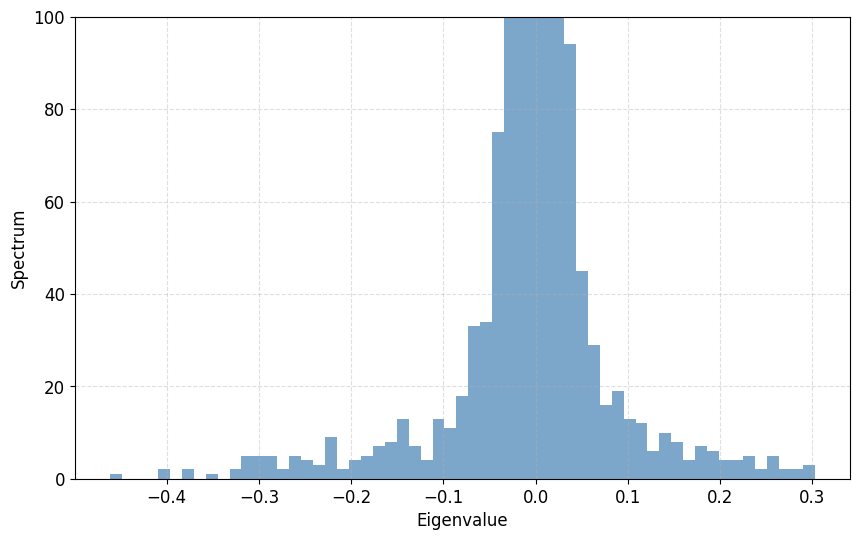

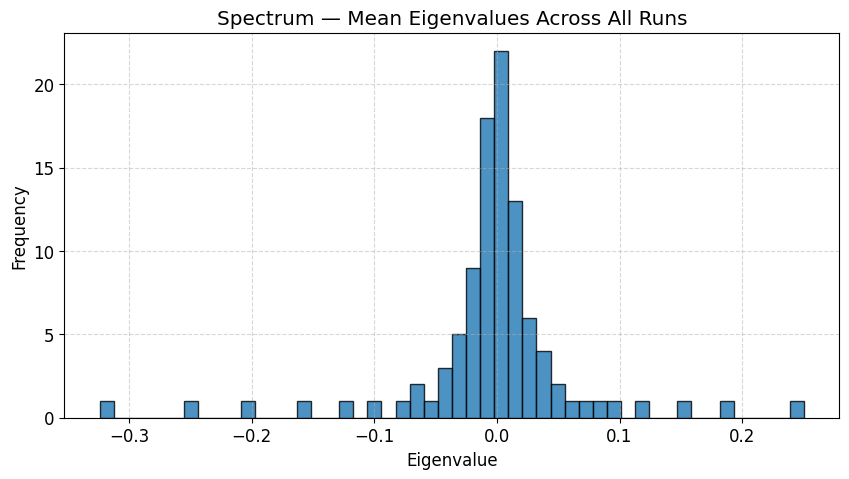

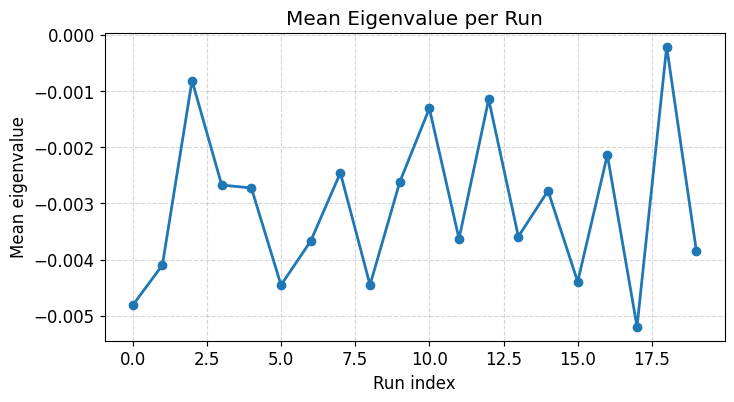

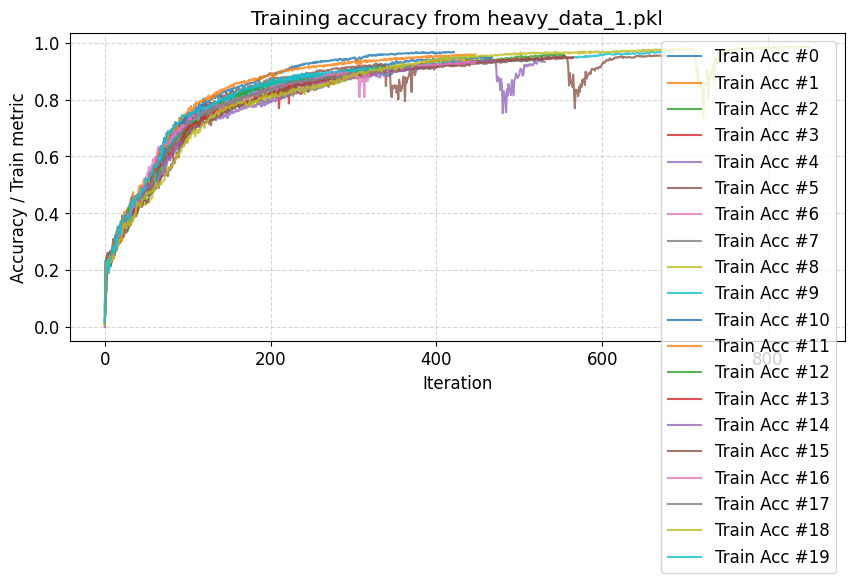

--- File: ../results/run_20251201_2051/heavy_data_10.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.008509


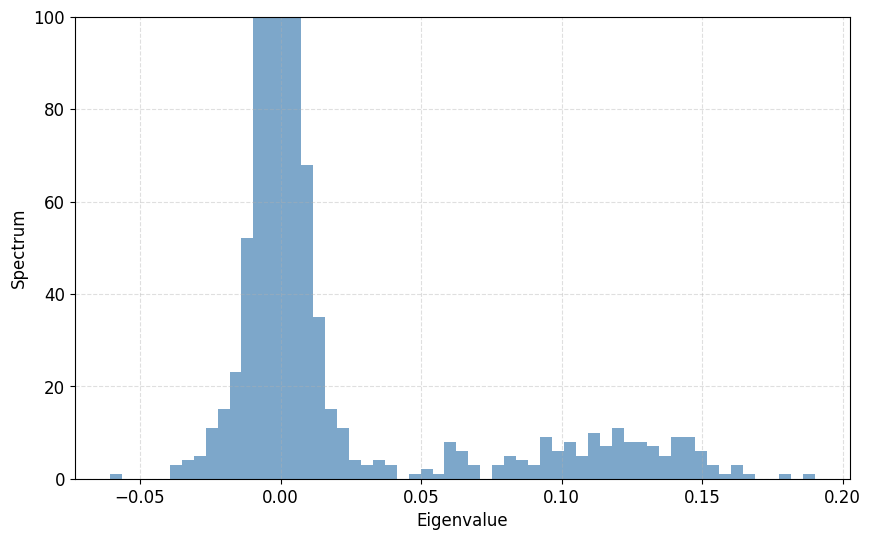

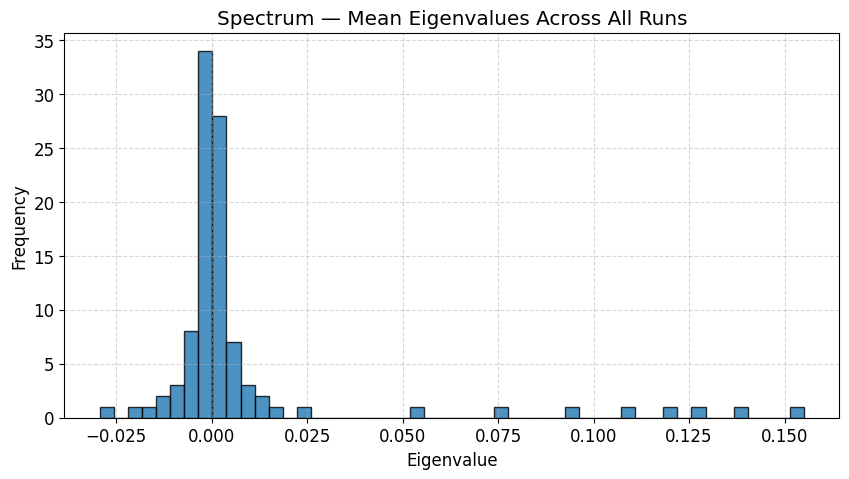

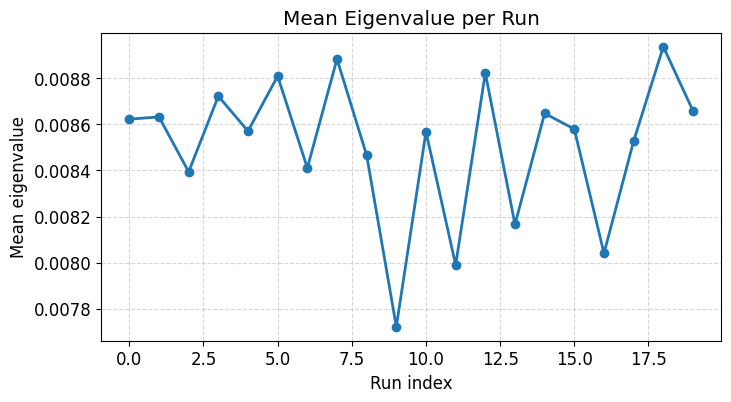

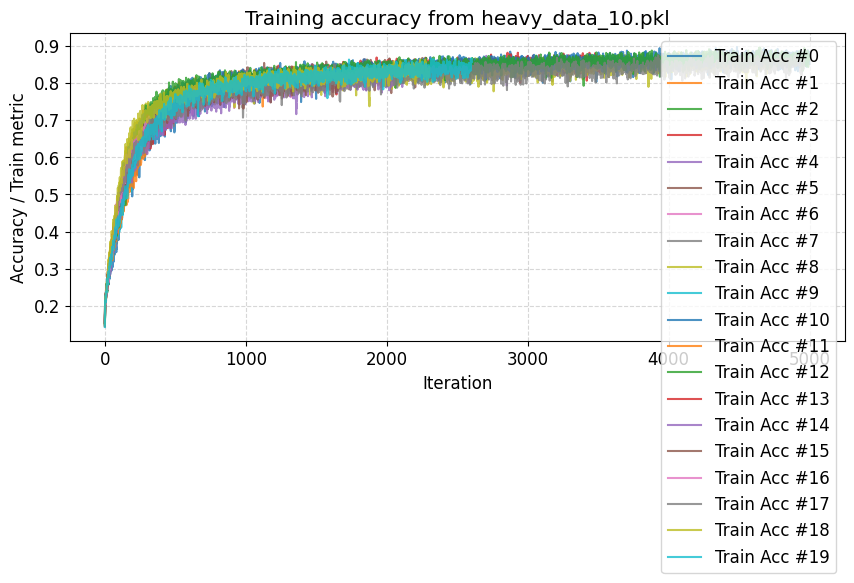

--- File: ../results/run_20251201_2051/heavy_data_11.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.007583


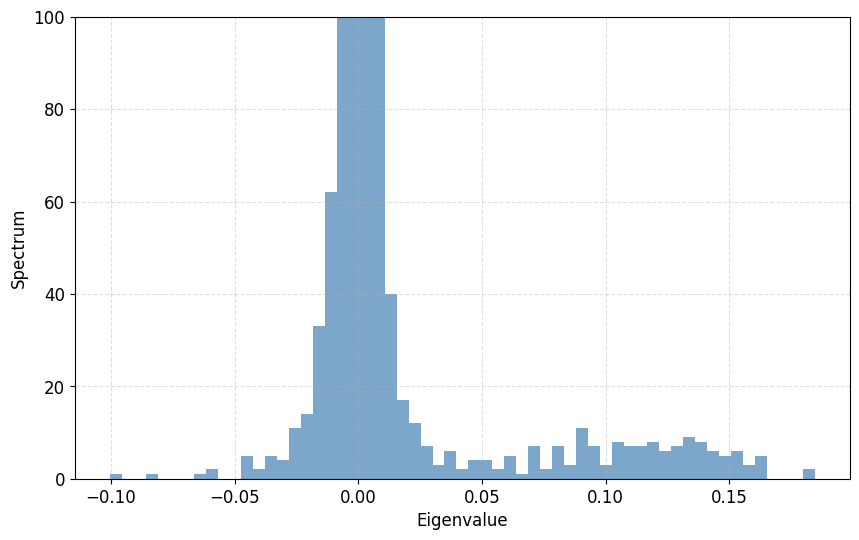

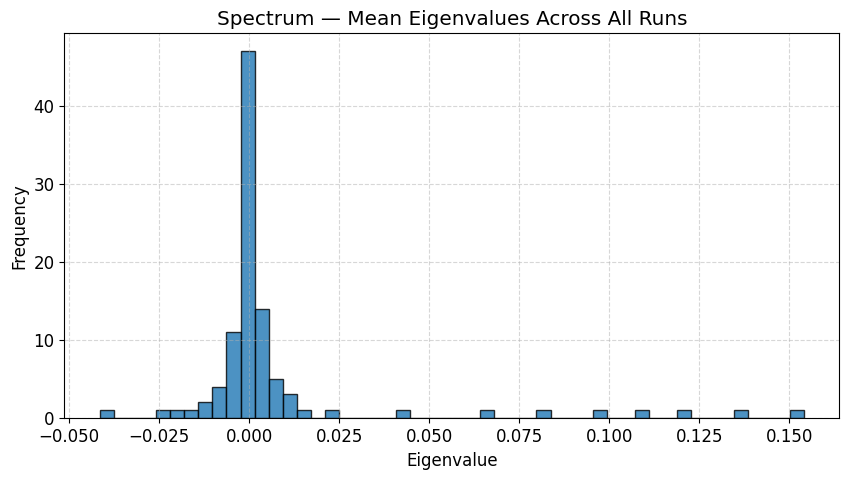

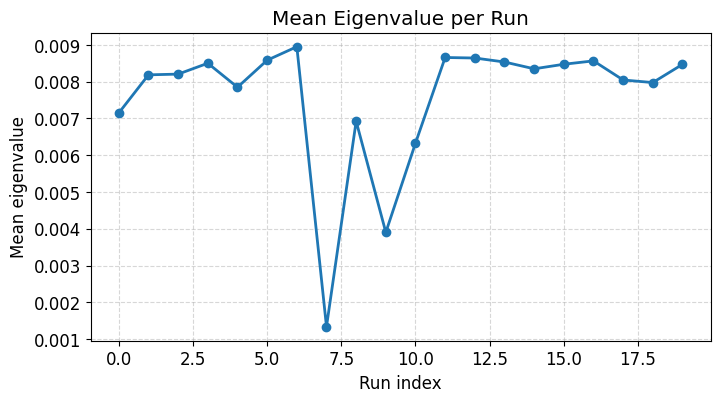

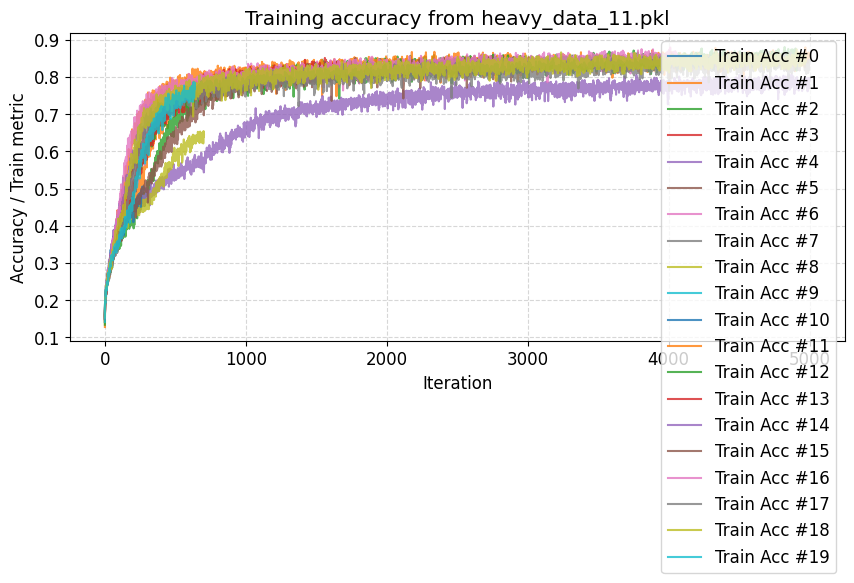

--- File: ../results/run_20251201_2051/heavy_data_12.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.008640


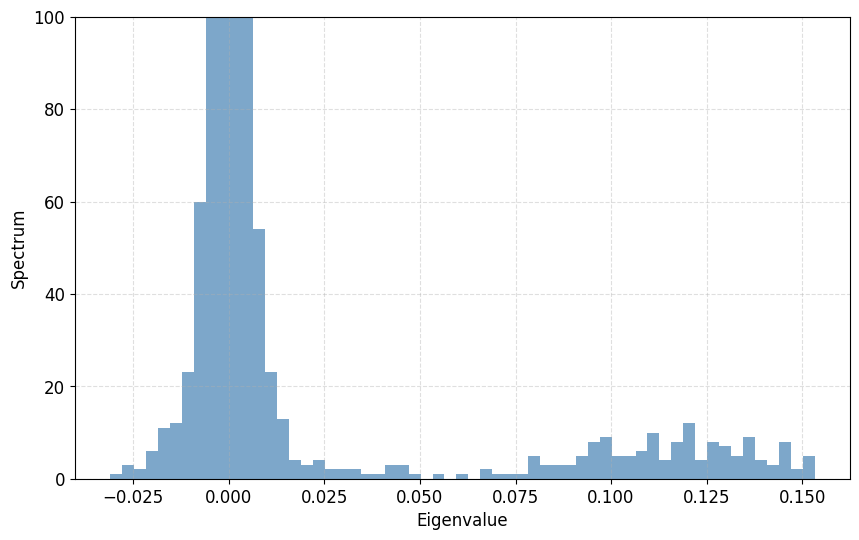

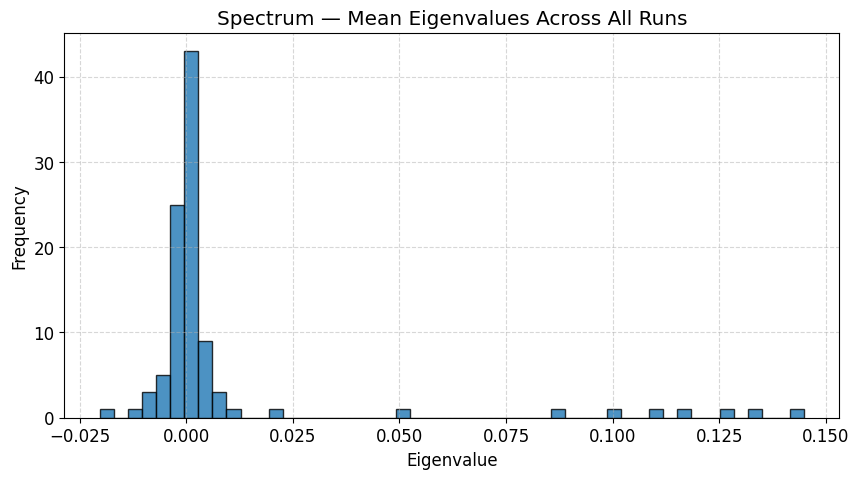

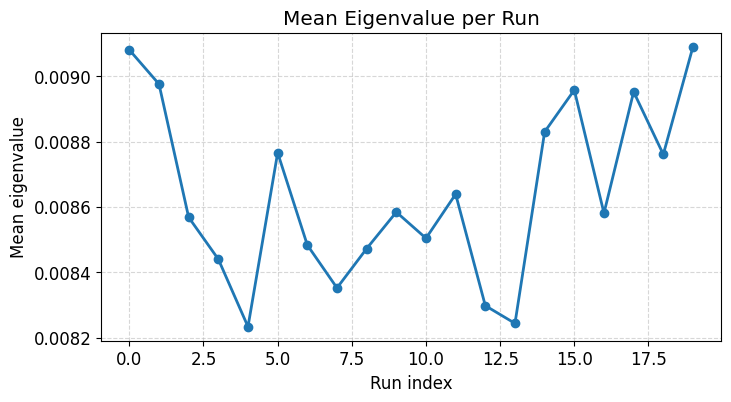

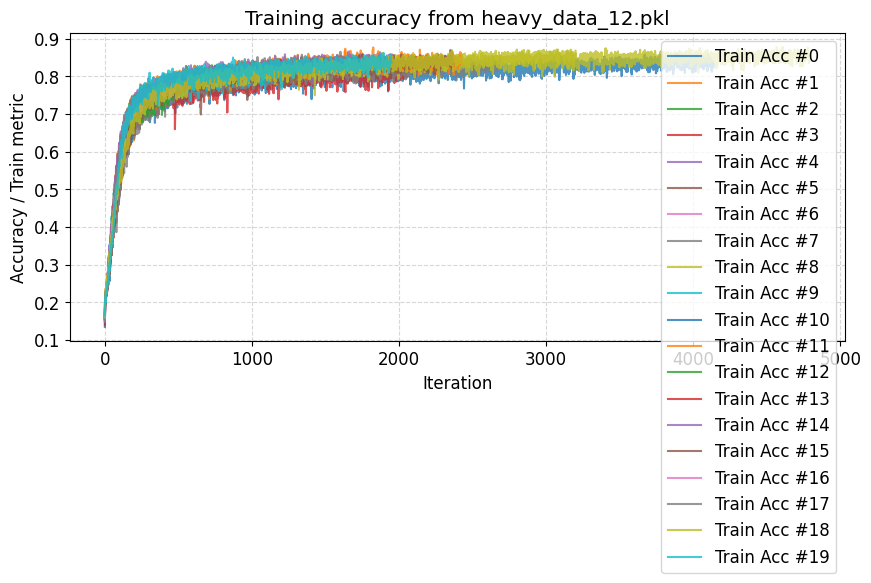

--- File: ../results/run_20251201_2051/heavy_data_13.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.008661


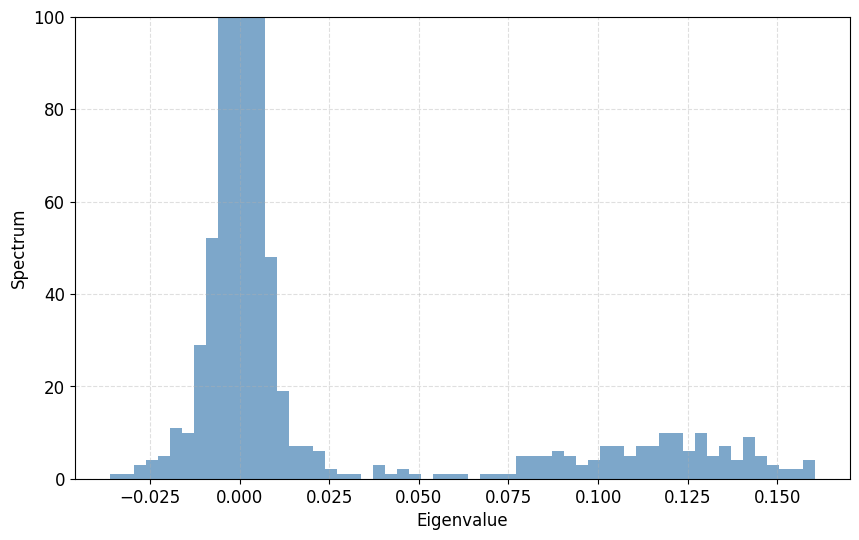

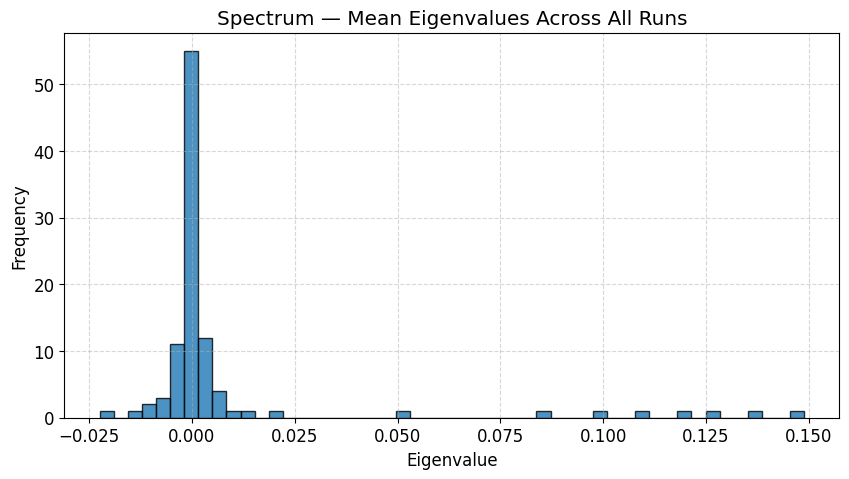

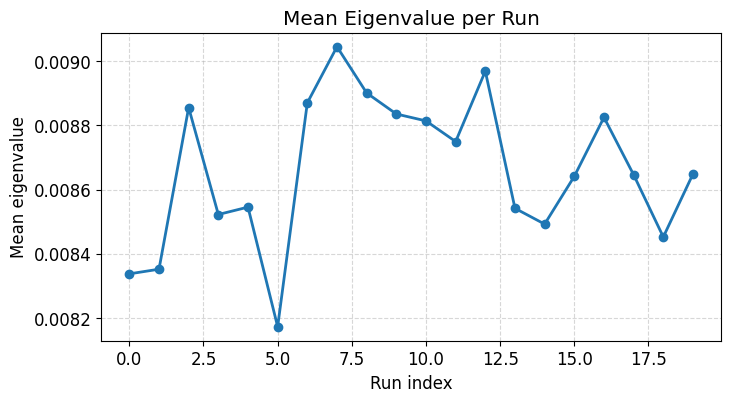

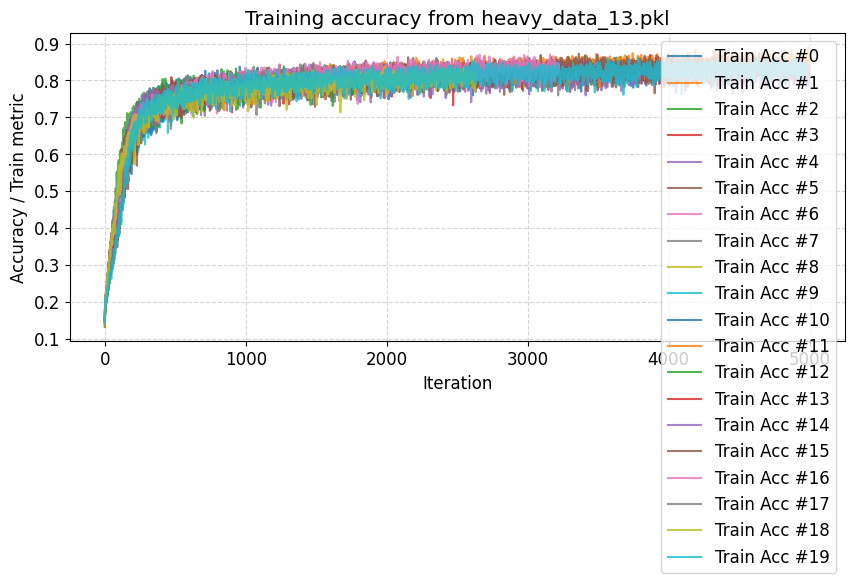

--- File: ../results/run_20251201_2051/heavy_data_14.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.008377


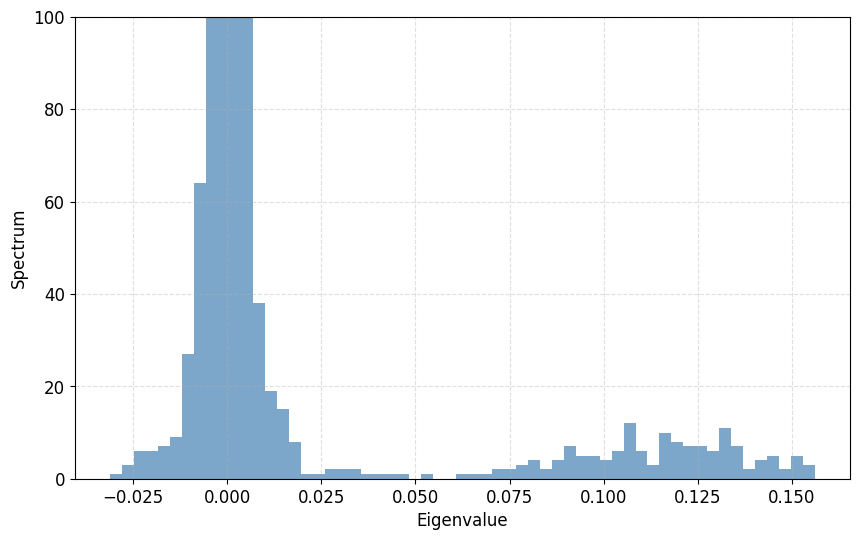

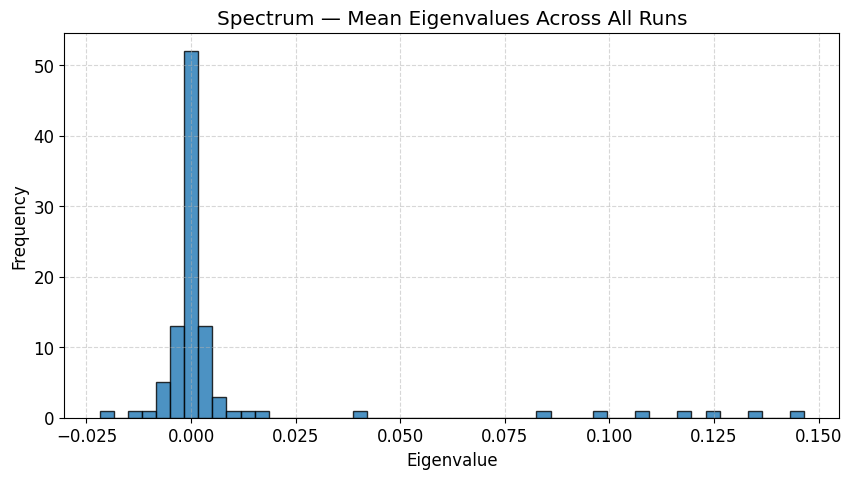

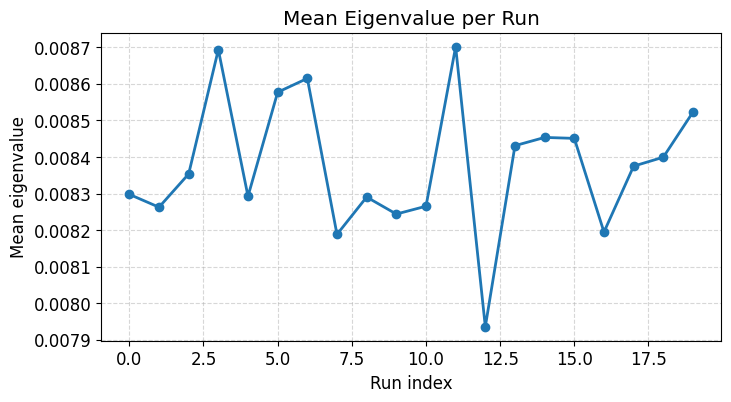

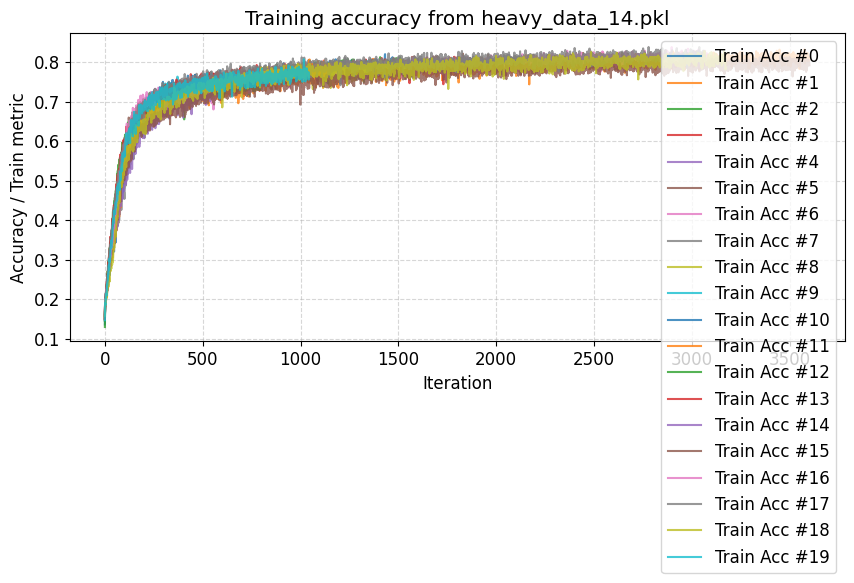

--- File: ../results/run_20251201_2051/heavy_data_2.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.001364


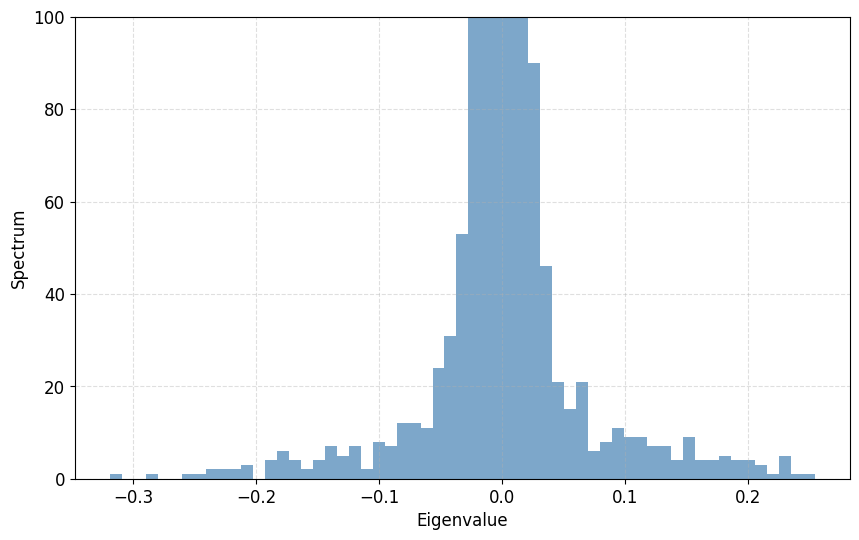

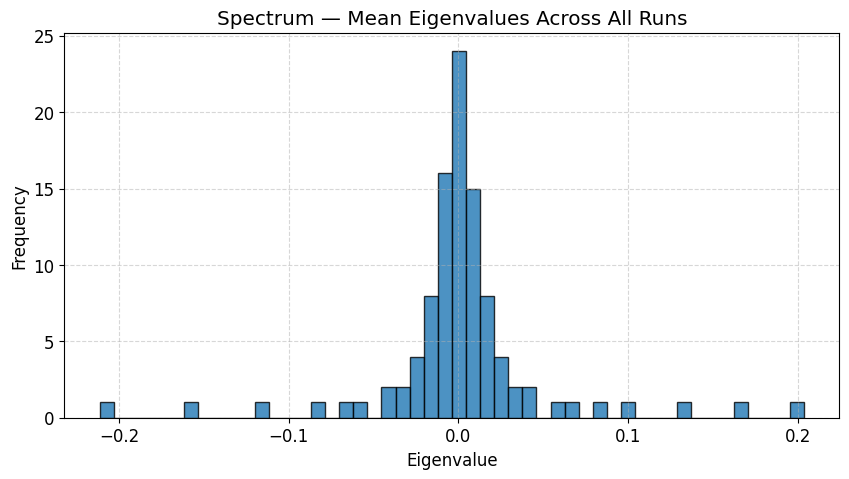

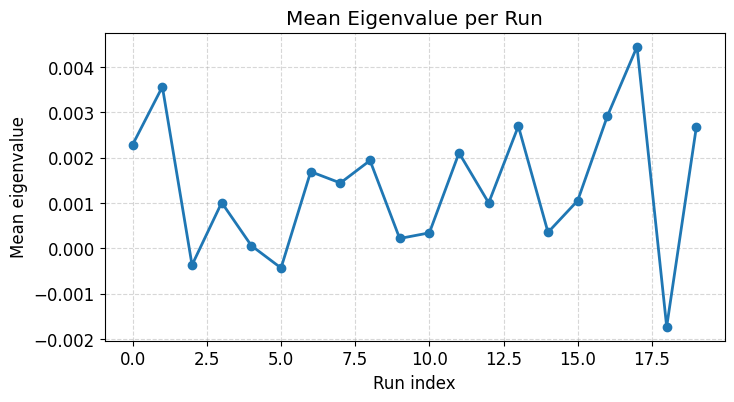

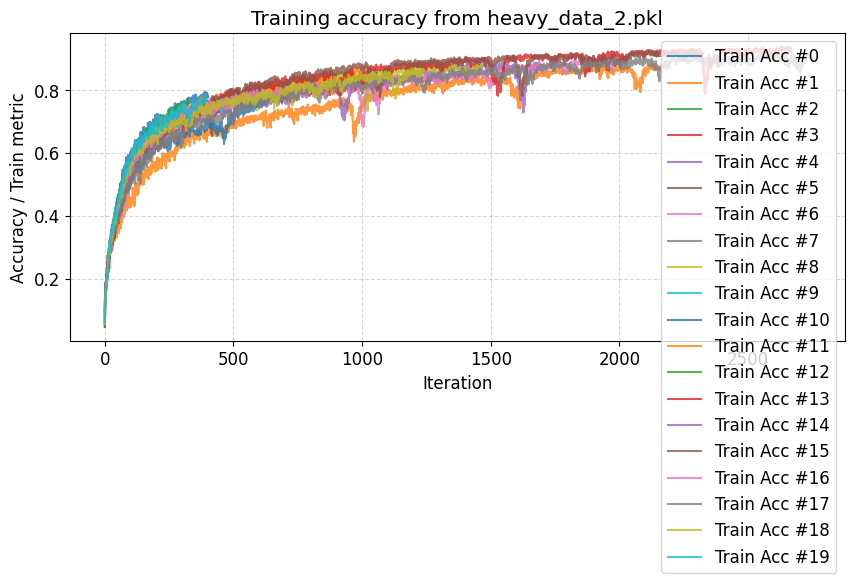

--- File: ../results/run_20251201_2051/heavy_data_3.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.001178


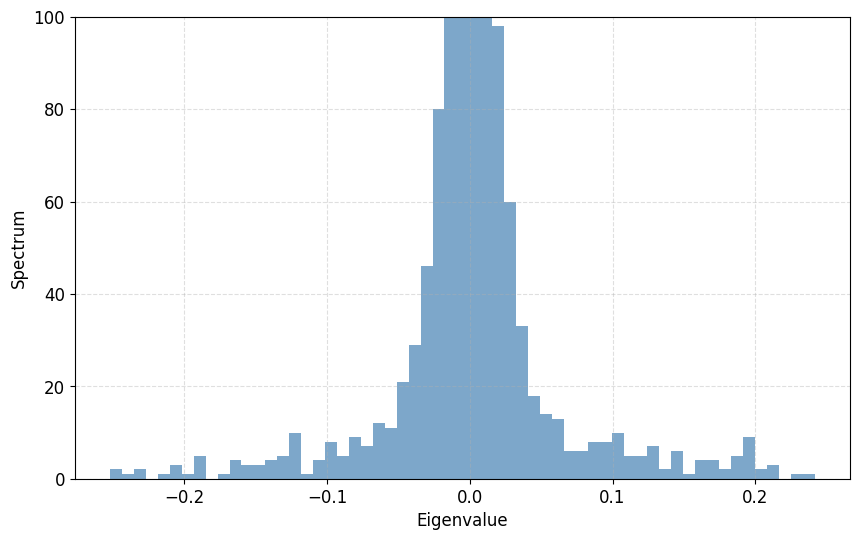

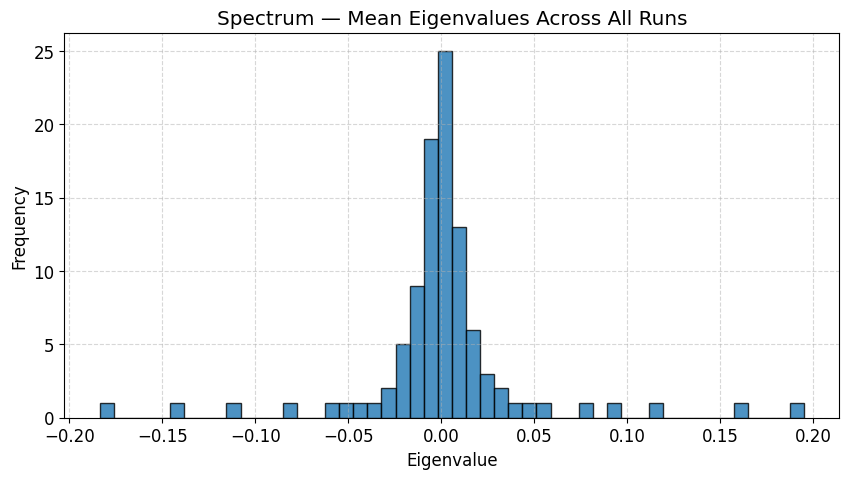

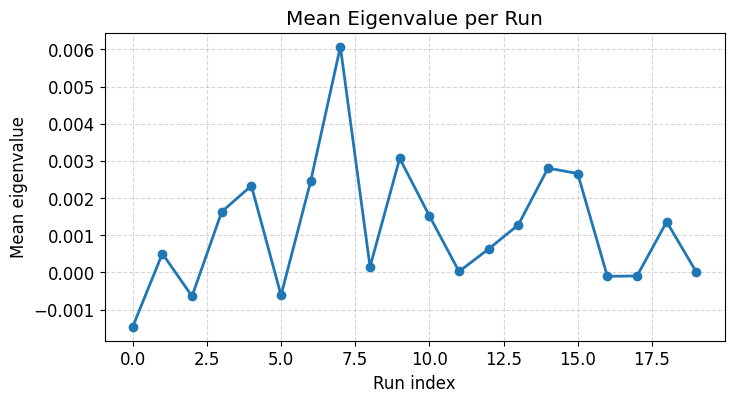

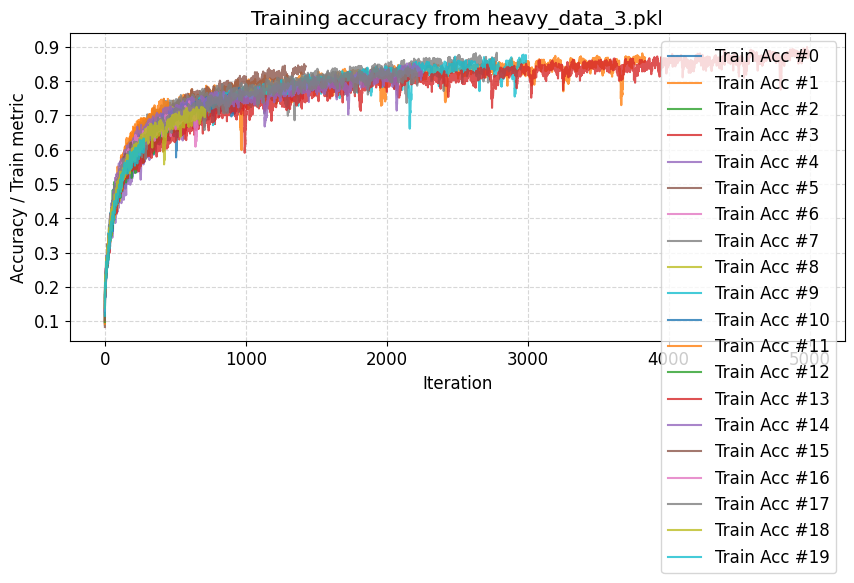

--- File: ../results/run_20251201_2051/heavy_data_4.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.006670


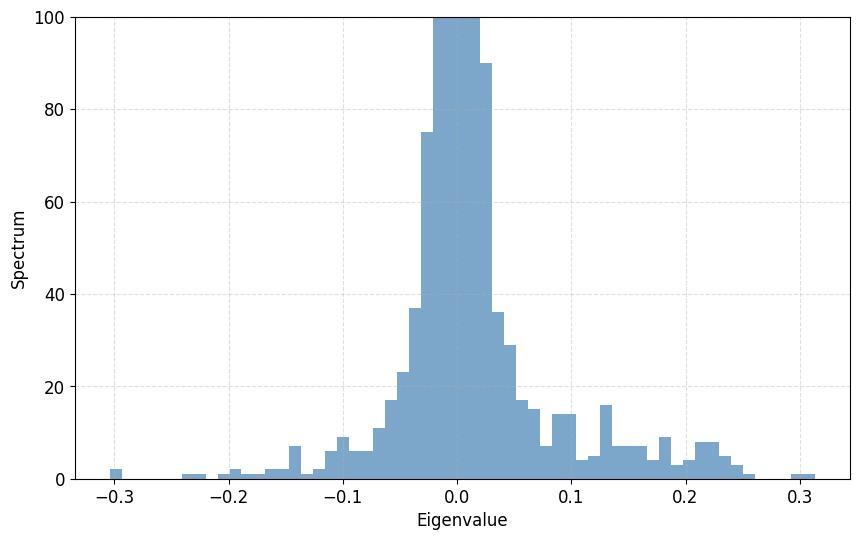

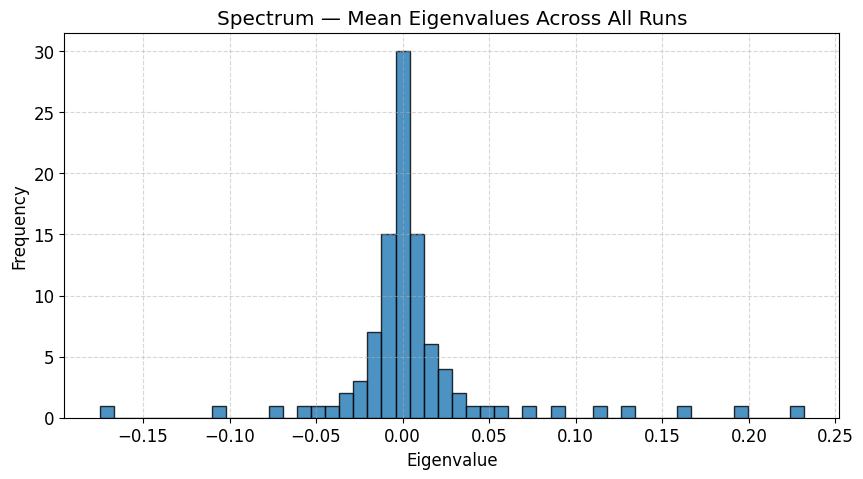

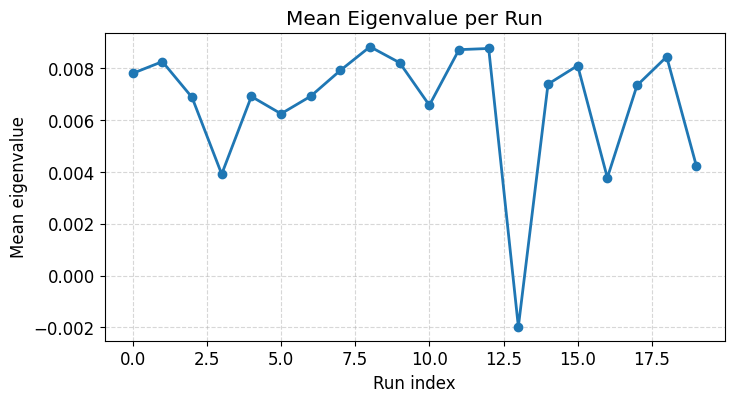

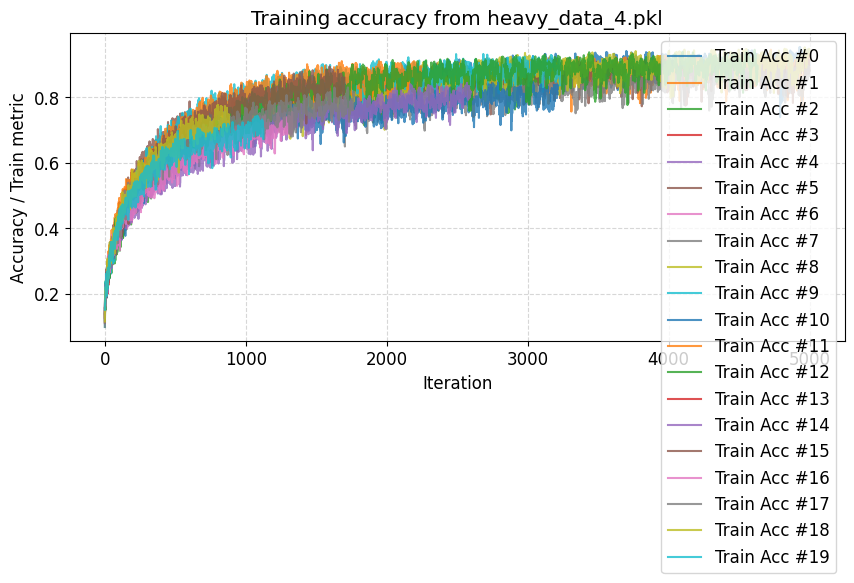

--- File: ../results/run_20251201_2051/heavy_data_5.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.005103


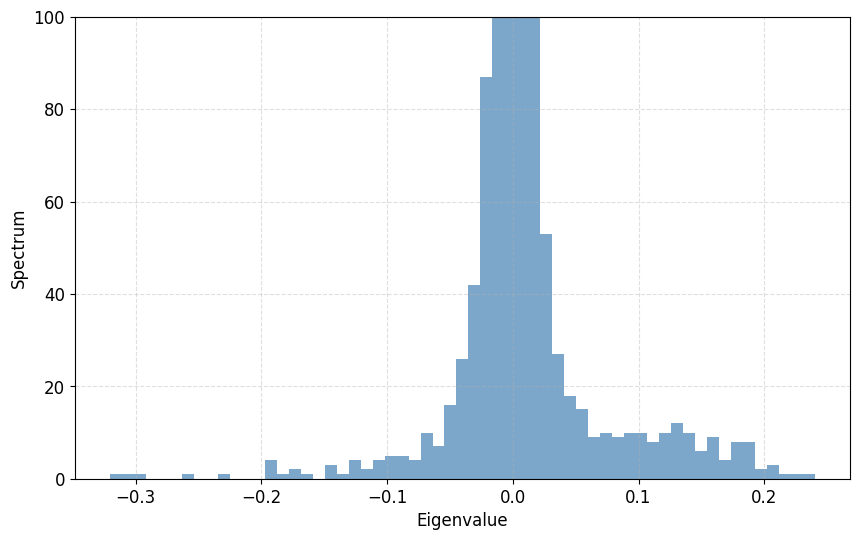

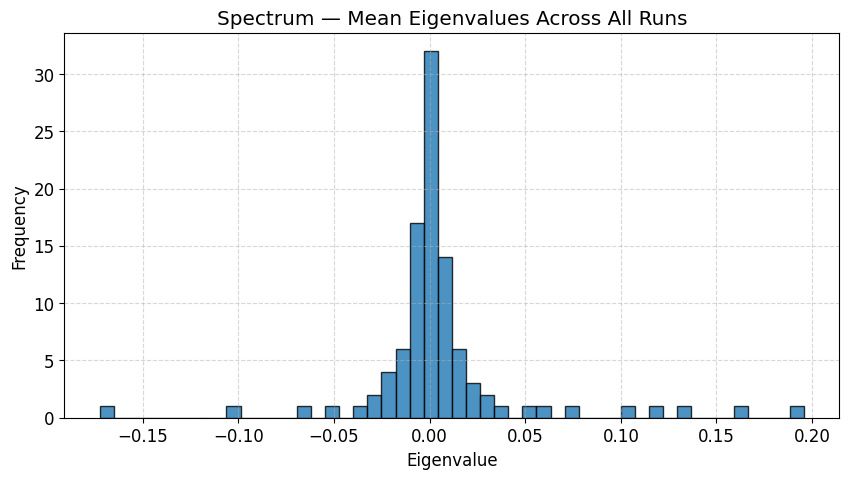

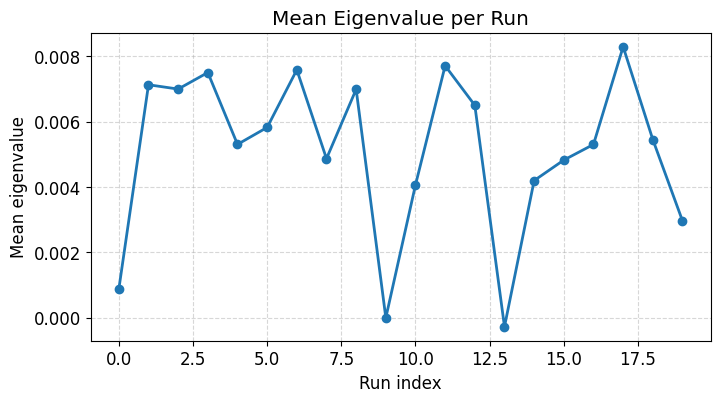

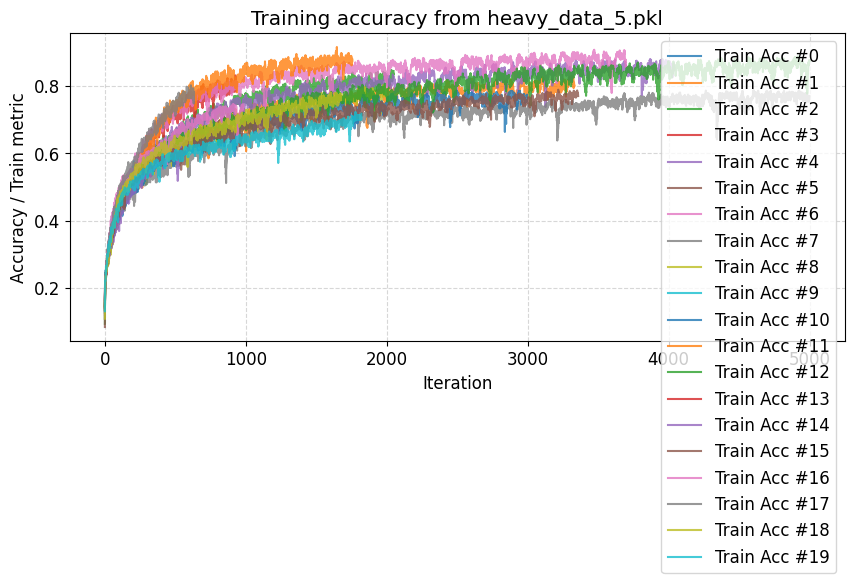

--- File: ../results/run_20251201_2051/heavy_data_6.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.007807


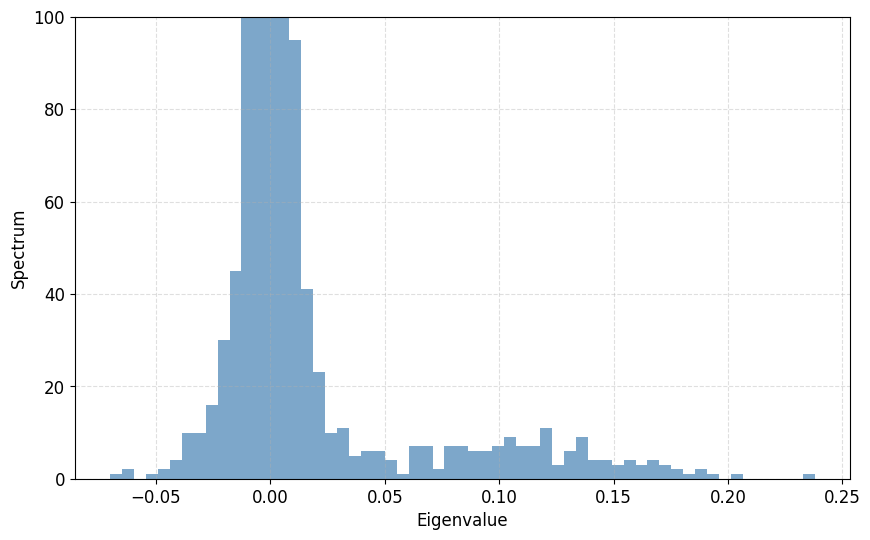

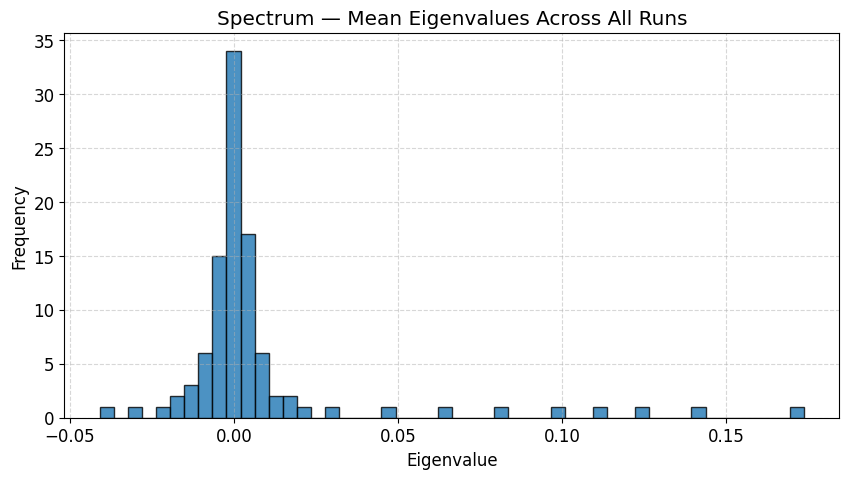

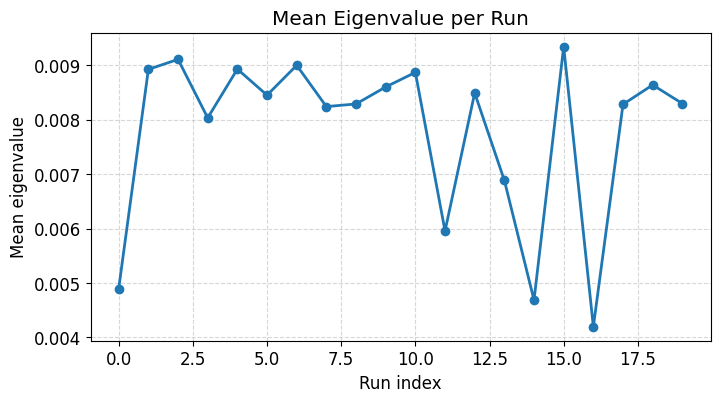

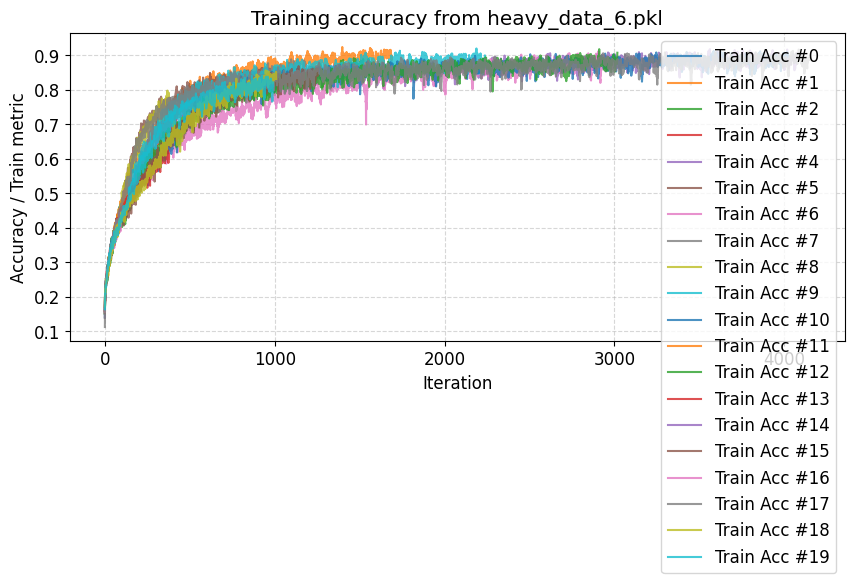

--- File: ../results/run_20251201_2051/heavy_data_7.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.005345


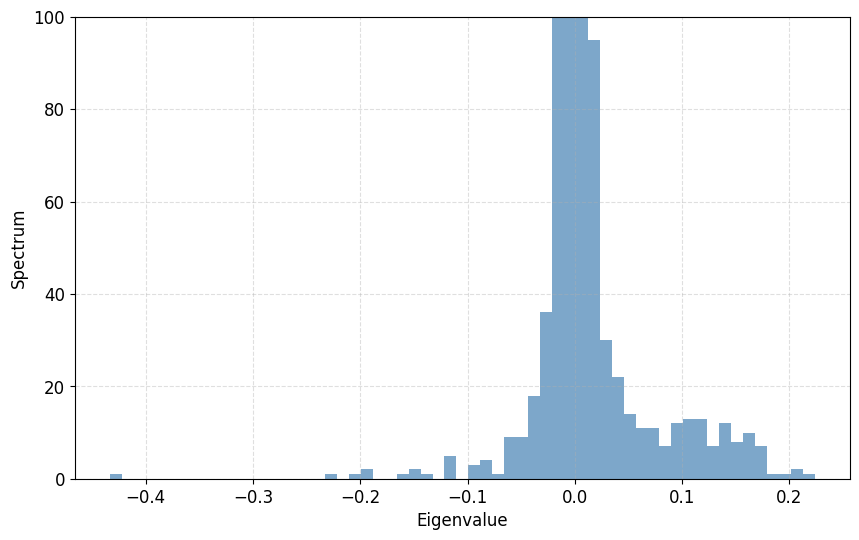

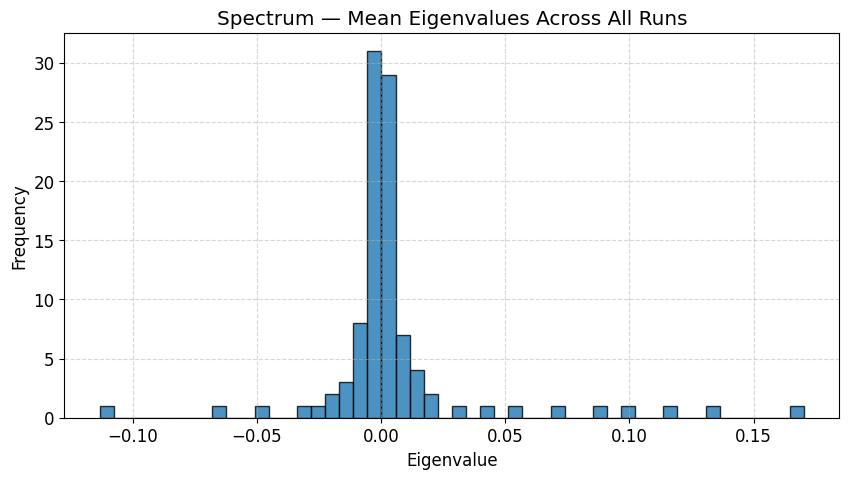

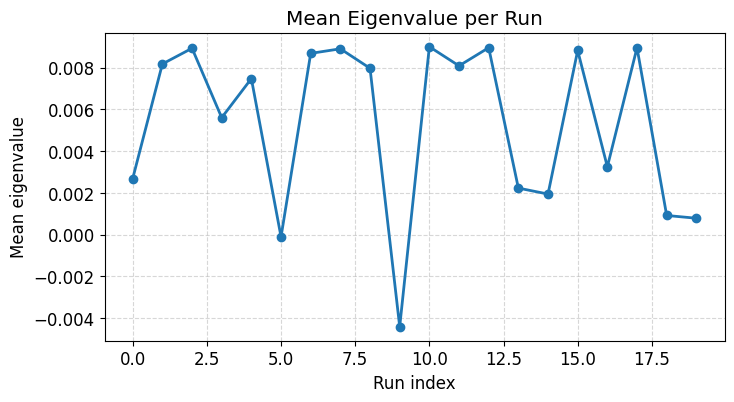

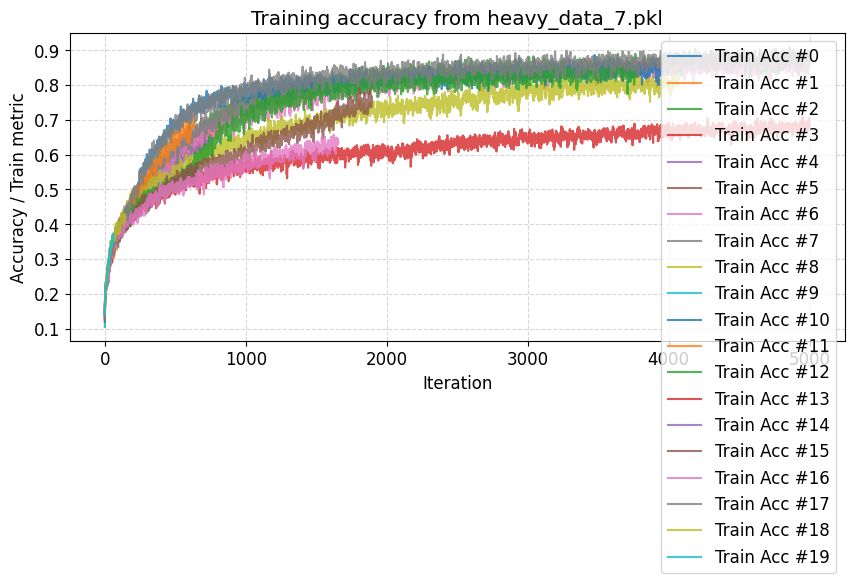

--- File: ../results/run_20251201_2051/heavy_data_8.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.008571


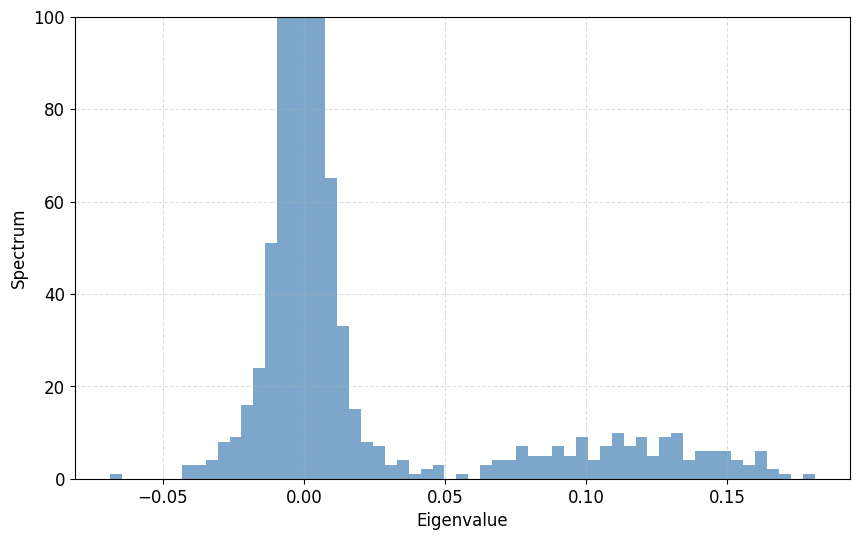

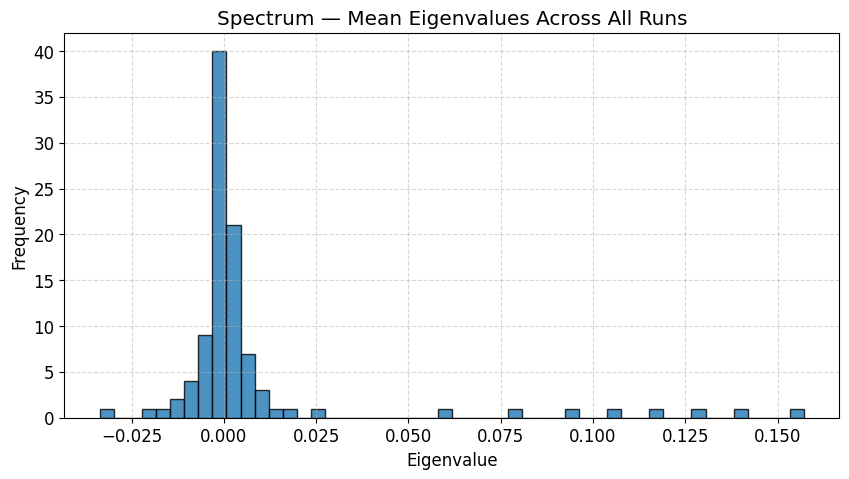

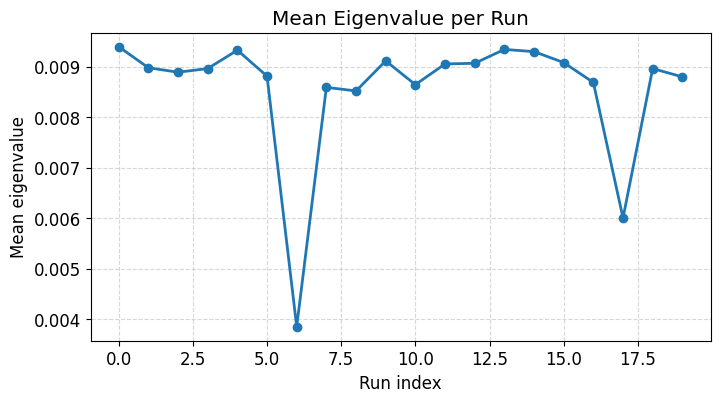

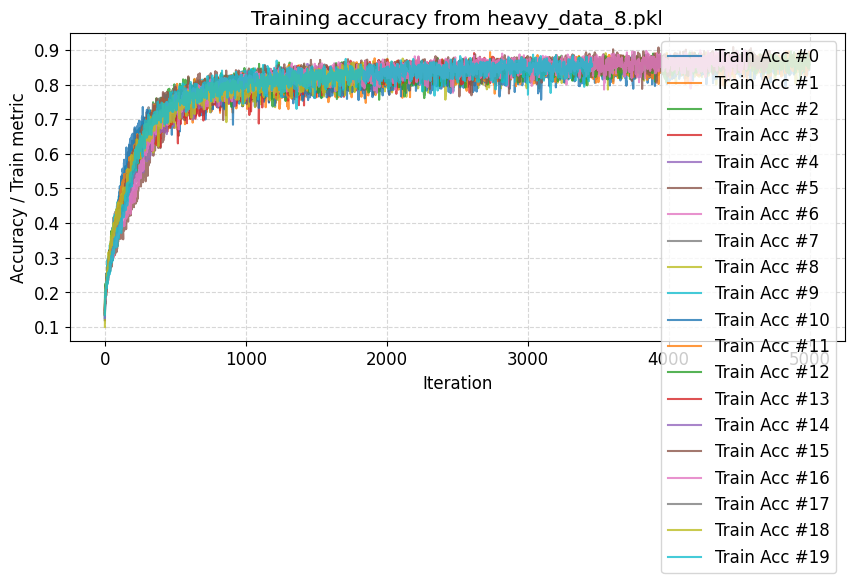

--- File: ../results/run_20251201_2051/heavy_data_9.pkl ---
W_runs: type=list, length=20
  first element shape: (100, 100), dtype=float32
acc_train: type=list, length=20
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 0.008566


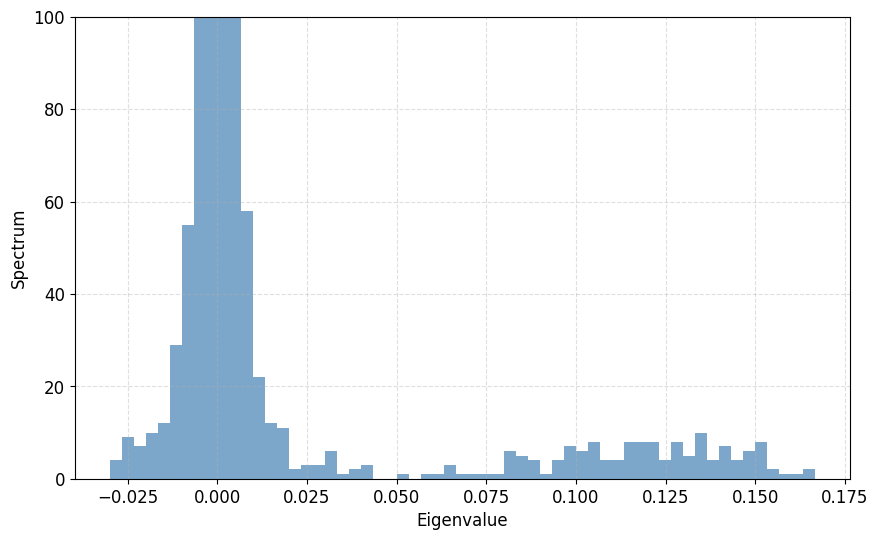

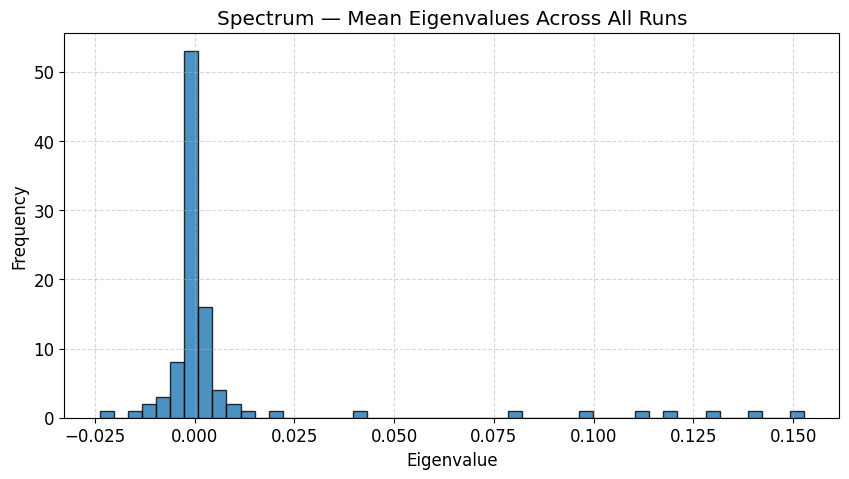

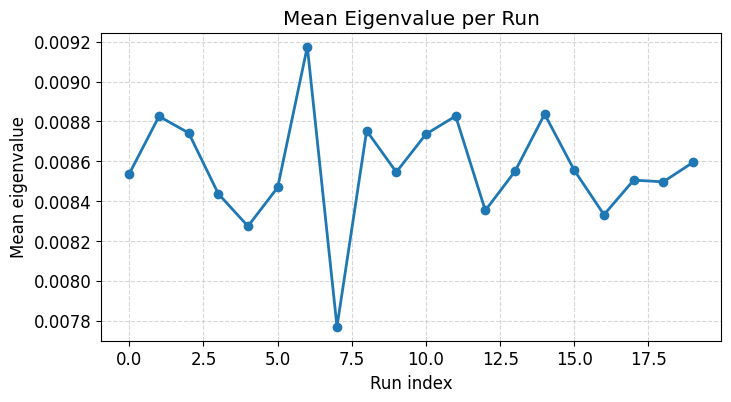

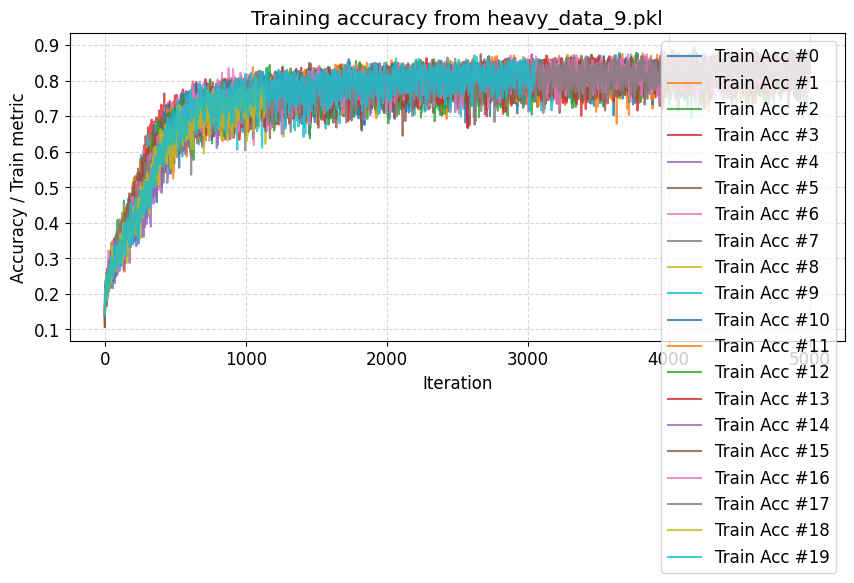

In [5]:
def highlight_diagonal(ax, seq_len, color='red', lw=2):
    """Draw rectangles along the diagonal of a matrix plot"""
    for i in range(seq_len):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, color=color, lw=lw)
        ax.add_patch(rect)

def plot_heavy_data_with_metrics(run_dir, max_plots=5, overlay_y_samples=True, show_shapes=True):
    """
    Plot eigenvalue spectra, attention matrices, sequence samples, and acc_train from the heavy_data pickle.
    Only plots up to max_plots λ values per run.
    overlay_y_samples: if True, plots y_samples overlay on attention matrices.
    show_shapes: if True, prints all keys with type/shape info.
    """
    heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
    print(f"Found {len(heavy_files)} heavy_data files.\n")

    for heavy_file in heavy_files:
        print(f"--- File: {heavy_file} ---")
        with open(heavy_file, "rb") as f:
            data = pickle.load(f)
        
        if show_shapes:
            # Afficher toutes les clés et shape/type
            for key, val in data.items():
                if isinstance(val, np.ndarray):
                    print(f"{key}: type={type(val)}, shape={val.shape}, dtype={val.dtype}")
                elif isinstance(val, torch.Tensor):
                    print(f"{key}: type={type(val)}, shape={val.shape}, dtype={val.dtype}")
                elif isinstance(val, list):
                    print(f"{key}: type=list, length={len(val)}")
                    if len(val) > 0:
                        first = val[0]
                        if isinstance(first, np.ndarray):
                            print(f"  first element shape: {first.shape}, dtype={first.dtype}")
                        elif isinstance(first, torch.Tensor):
                            print(f"  first element shape: {first.shape}, dtype={first.dtype}")
                        else:
                            print(f"  first element type: {type(first)}")
                else:
                    print(f"{key}: type={type(val)}")
            print("\n")

        W_runs_all = data.get("W_runs", [])
        attn_matrices = data.get("attn_matrices", [])
        seq_samples = data.get("seq_samples", [])
        y_samples = data.get("y_samples", None)
        acc_train = data.get("acc_train", None)

        # --- Plots Eigenvalue & Attention ---
        # --- Compute eigenvalue spectra for all W ---
        eigvals_runs = []

        for W in W_runs_all:
            eigvals = np.linalg.eigvalsh(W)/W.shape[0]  # Normalized eigenvalues
            eigvals_runs.append(eigvals)

        # --- Pad or truncate to match lengths (if needed) ---
        min_len = min(len(ev) for ev in eigvals_runs)
        eigvals_runs = np.array([ev[:min_len] for ev in eigvals_runs])

        # --- Mean eigenvalues per run ---
        mean_per_run = eigvals_runs.mean(axis=1)

        # --- Global mean of means (as requested) ---
        global_mean_mean = mean_per_run.mean()

        print(f"📊 Global mean of averaged eigenvalues = {global_mean_mean:.6f}")

        plt.figure(figsize=(10, 6))

        # Déterminer les bins communs pour tous les runs
        all_eigvals = np.concatenate([np.linalg.eigvalsh(W)/W.shape[0] for W in W_runs_all])
        bins = np.linspace(all_eigvals.min(), all_eigvals.max(), 60)

        # Cumuler les histogrammes
        cum_hist = np.zeros(len(bins)-1)
        for W in W_runs_all:
            eigvals = np.linalg.eigvalsh(W)/W.shape[0]
            hist, _ = np.histogram(eigvals, bins=bins)
            cum_hist += hist

        # Afficher le résultat
        plt.bar(
            (bins[:-1] + bins[1:])/2,  # centre des bins
            cum_hist,
            width=np.diff(bins),
            alpha=0.7,
            color='steelblue'
        )

        # plt.title("Cumulative Eigenvalue Spectra")
        plt.xlabel("Eigenvalue")
        plt.ylabel("Spectrum")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.ylim(0, 100)
        plt.savefig(
            os.path.join(plot_path, f"Cumulative Eigenvalue Spectra - {os.path.basename(heavy_file)}.png"),
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

        # --- Plot 1: Histogram of all eigenvalues averaged across runs ---
        plt.figure(figsize=(10, 5))
        plt.hist(eigvals_runs.mean(axis=0), bins=50, alpha=0.8, edgecolor="black")
        plt.title("Spectrum — Mean Eigenvalues Across All Runs")
        plt.xlabel("Eigenvalue")
        plt.ylabel("Frequency")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

        # --- Plot 2 (optional): per-run mean eigenvalues ---
        plt.figure(figsize=(8, 4))
        plt.plot(mean_per_run, marker='o', lw=2)
        plt.title("Mean Eigenvalue per Run")
        plt.xlabel("Run index")
        plt.ylabel("Mean eigenvalue")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

        # --- Plot acc_train ---
        if len(acc_train) > 0:
            plt.figure(figsize=(10,4))

            for i, acc_vals in enumerate(acc_train):
                # Convertir torch tensor / list en numpy
                if isinstance(acc_vals, list):
                    acc_vals = np.array(acc_vals)
                elif hasattr(acc_vals, "detach"):  # torch tensor
                    acc_vals = acc_vals.detach().cpu().numpy()

                plt.plot(acc_vals, lw=1.5, alpha=0.8, label=f"Train Acc #{i}")

            plt.xlabel("Iteration")
            plt.ylabel("Accuracy / Train metric")
            plt.title(f"Training accuracy from {os.path.basename(heavy_file)}")
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.legend()
            plt.show()

# --- Usage ---
plot_heavy_data_with_metrics(run_dir, max_plots=5, overlay_y_samples=True, show_shapes=True)

Found 15 heavy_data files.

Processing: ../results/run_20251201_2051/heavy_data_0.pkl


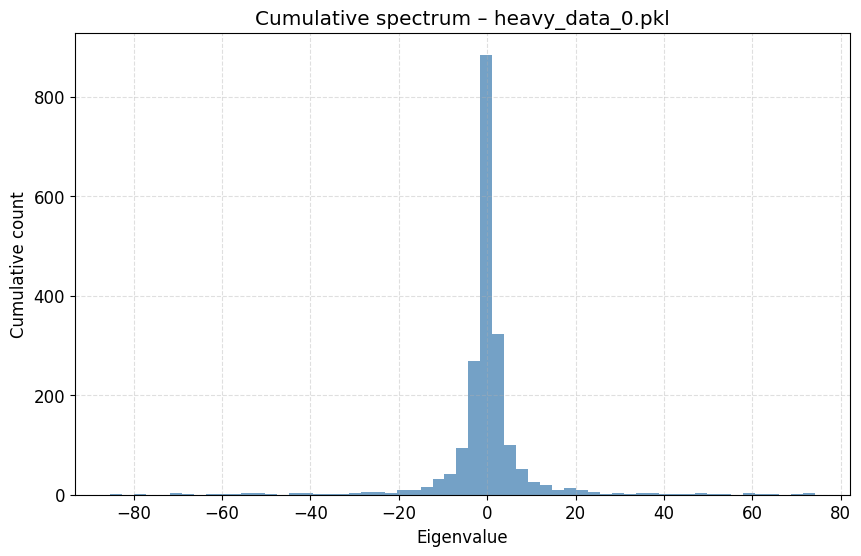

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_0.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_1.pkl


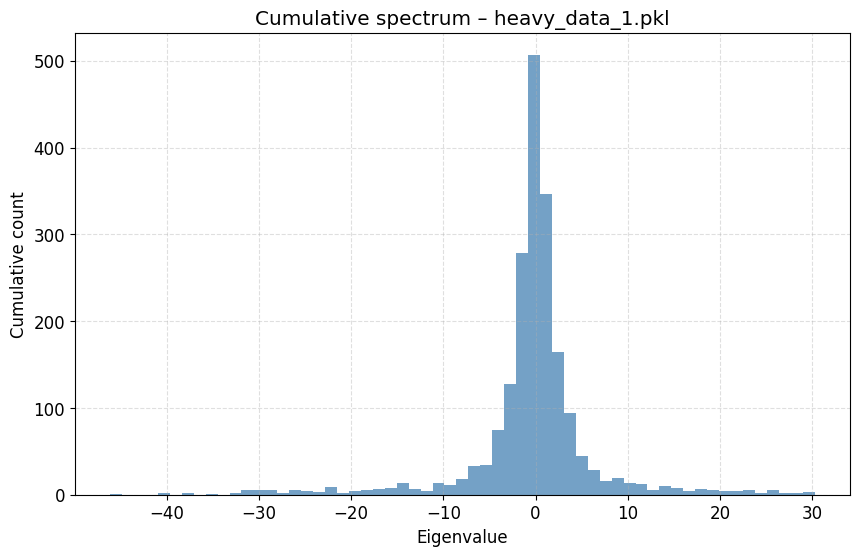

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_1.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_10.pkl


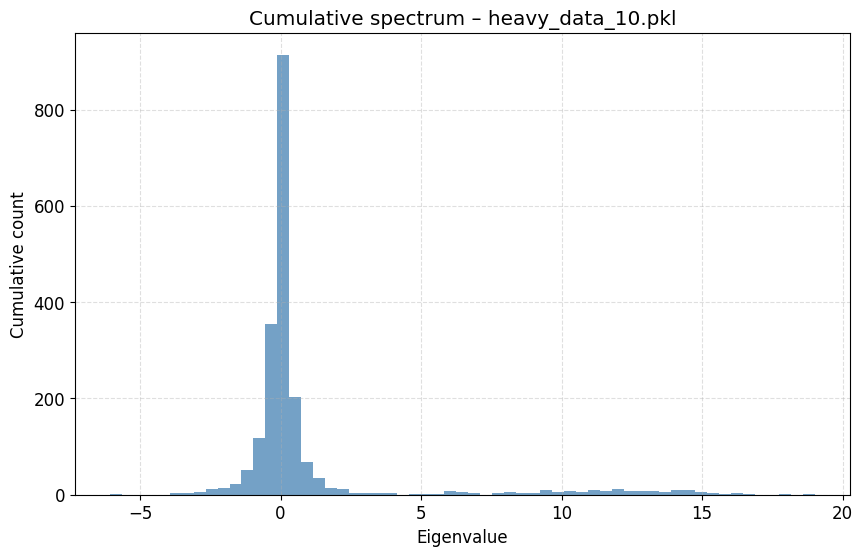

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_10.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_11.pkl


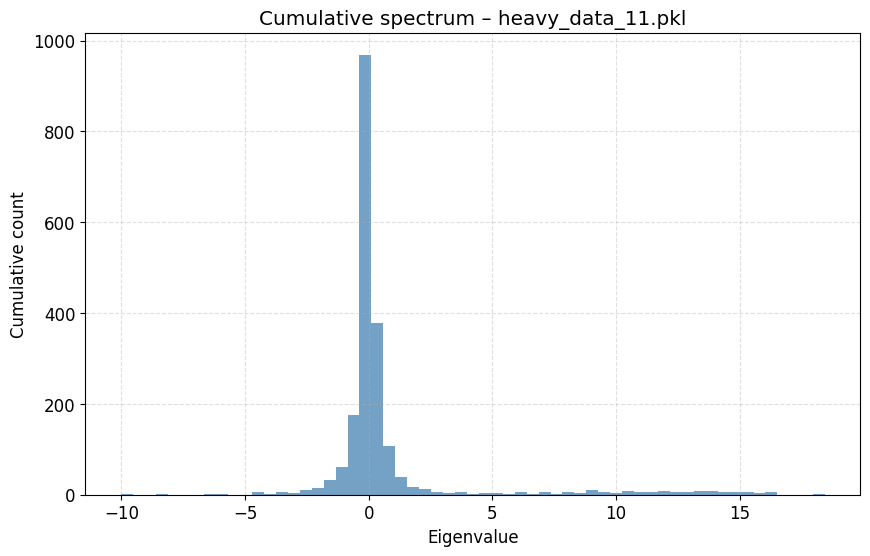

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_11.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_12.pkl


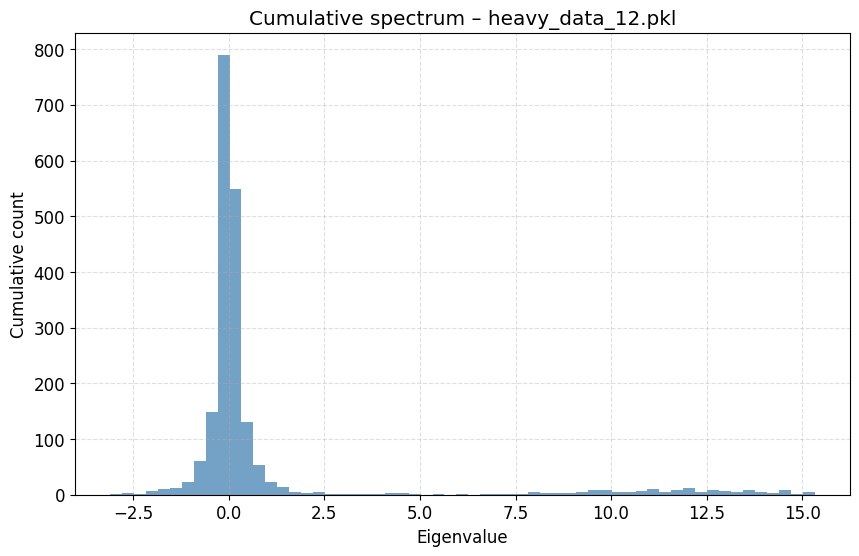

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_12.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_13.pkl


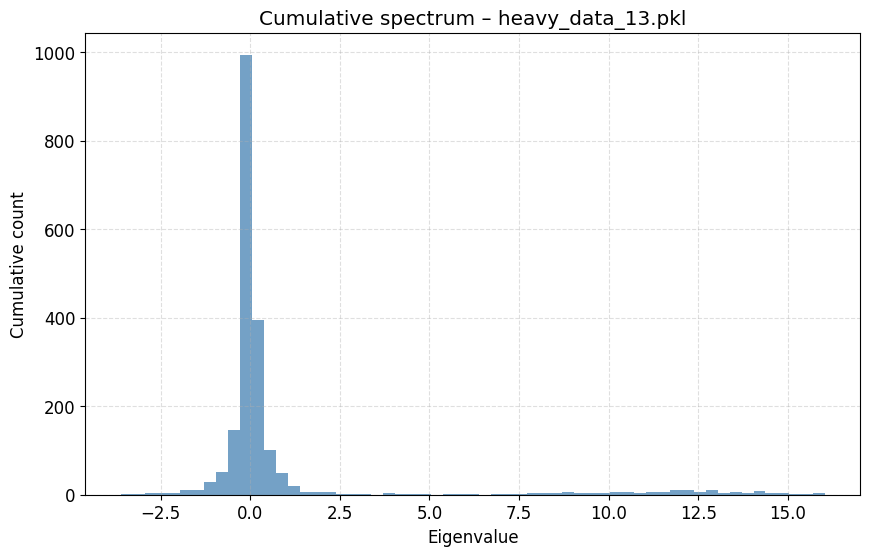

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_13.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_14.pkl


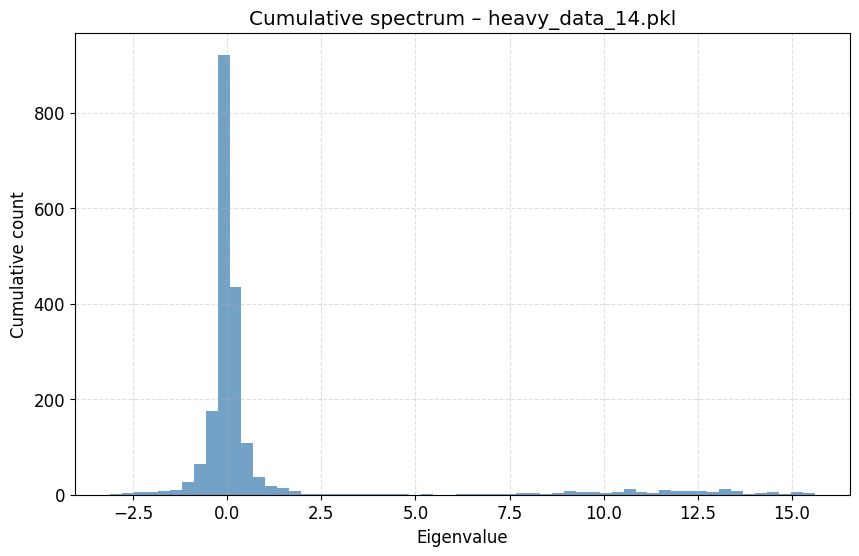

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_14.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_2.pkl


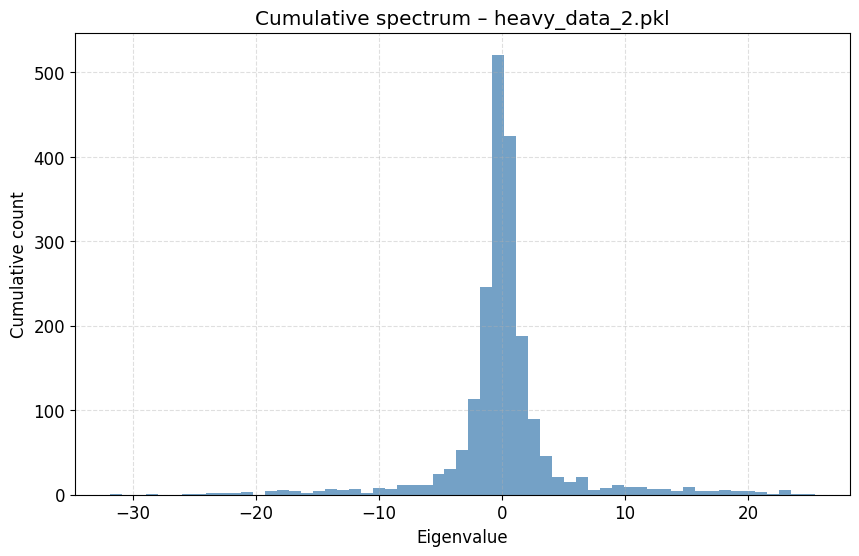

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_2.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_3.pkl


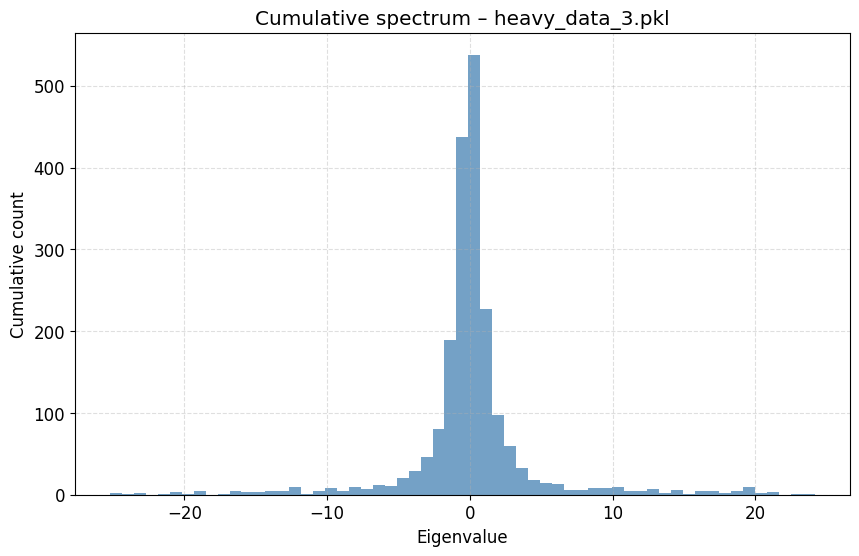

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_3.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_4.pkl


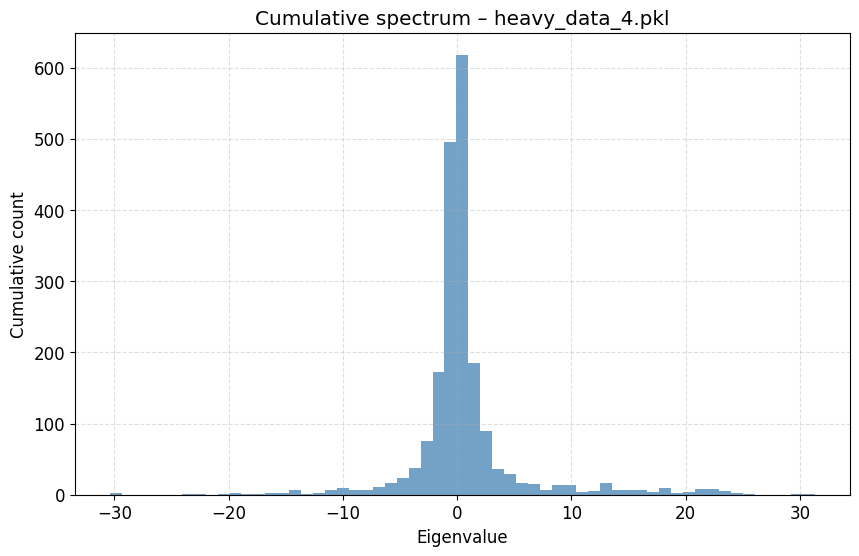

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_4.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_5.pkl


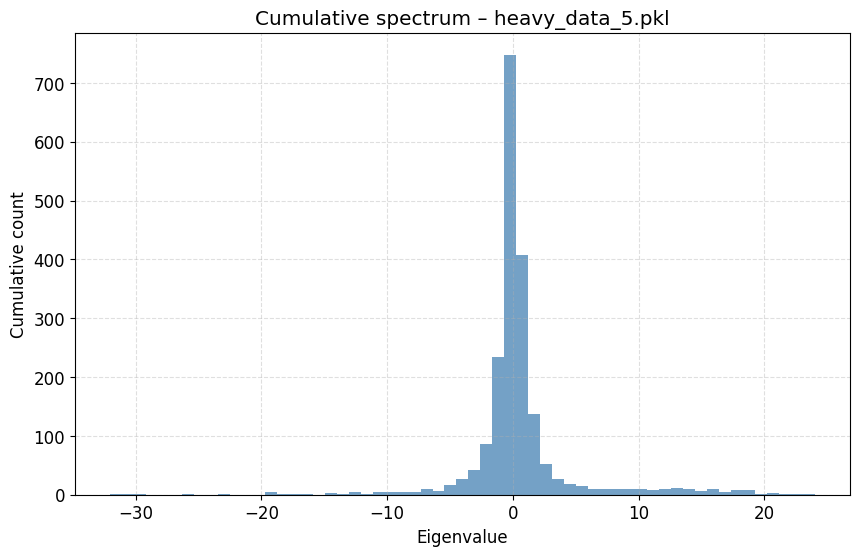

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_5.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_6.pkl


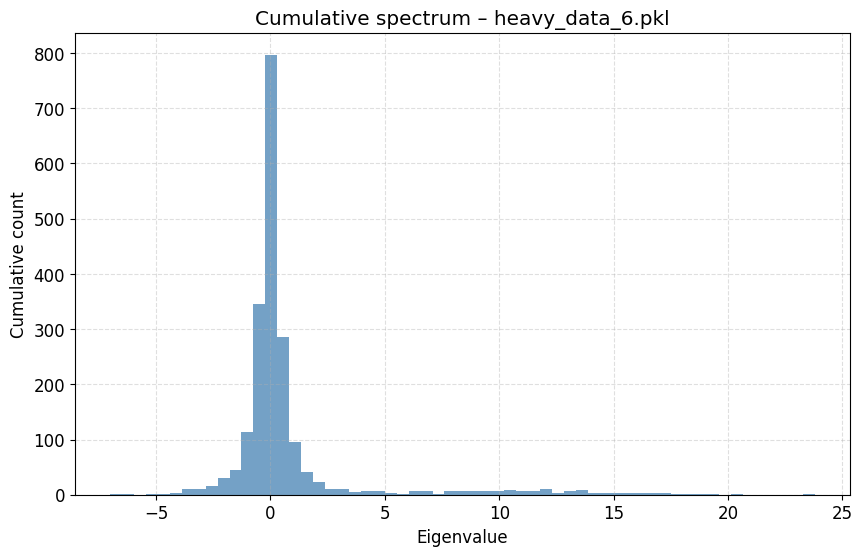

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_6.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_7.pkl


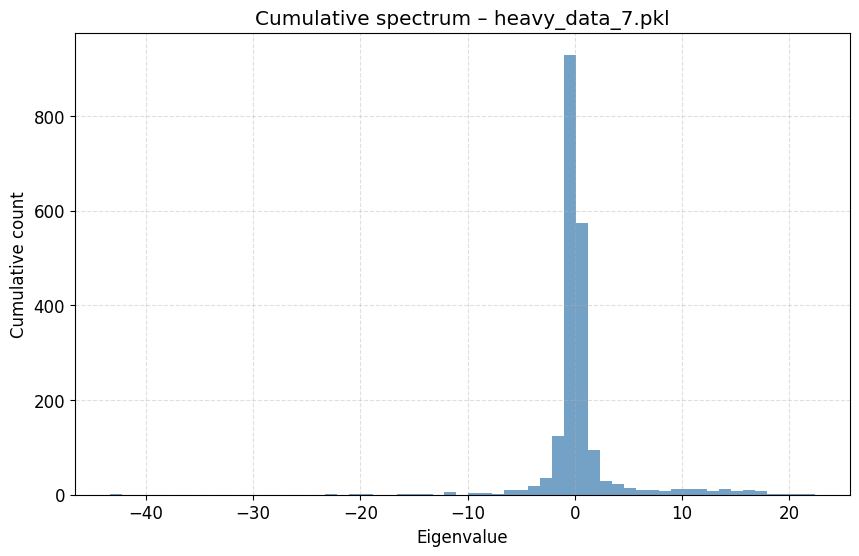

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_7.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_8.pkl


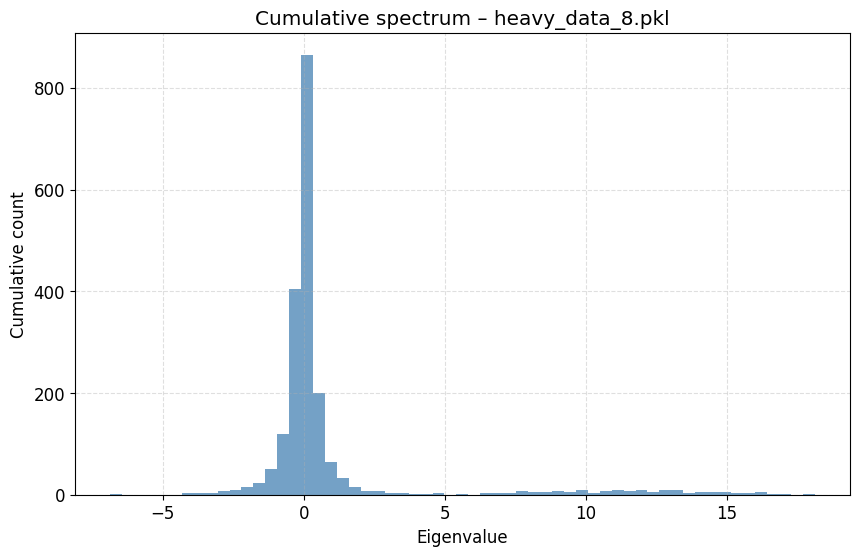

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_8.pkl.png

Processing: ../results/run_20251201_2051/heavy_data_9.pkl


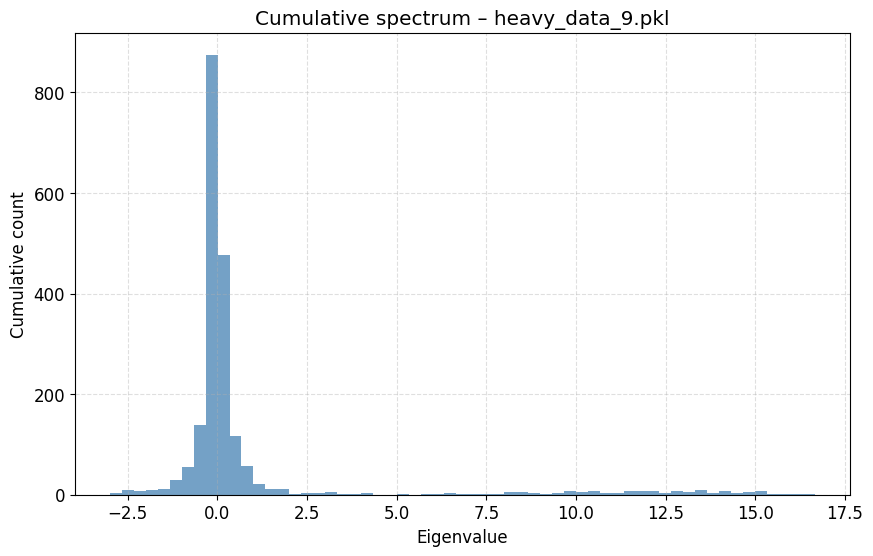

Saved cumulative plot to: ../results/run_20251201_2051/cum_spectrum_heavy_data_9.pkl.png



In [6]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt

def plot_cumulative_spectra(run_dir, bins_count=60):
    heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
    print(f"Found {len(heavy_files)} heavy_data files.\n")

    for heavy_file in heavy_files:
        print(f"Processing: {heavy_file}")

        # Load the file
        with open(heavy_file, "rb") as f:
            data = pickle.load(f)

        W_runs_all = data.get("W_runs", [])
        if len(W_runs_all) == 0:
            print("⚠️ No W_runs found in this file.\n")
            continue

        # Gather all eigenvalues (from all W)
        all_eigvals = np.concatenate([np.linalg.eigvalsh(W) for W in W_runs_all])

        # Build histogram bins
        bins = np.linspace(all_eigvals.min(), all_eigvals.max(), bins_count)

        # Cumulative histogram
        cum_hist = np.zeros(len(bins) - 1)
        for W in W_runs_all:
            eigvals = np.linalg.eigvalsh(W)
            hist, _ = np.histogram(eigvals, bins=bins)
            cum_hist += hist

        # Plot cumulative spectrum
        plt.figure(figsize=(10, 6))
        centers = 0.5 * (bins[:-1] + bins[1:])

        plt.bar(
            centers,
            cum_hist,
            width=np.diff(bins),
            alpha=0.75,
            color='steelblue'
        )

        plt.xlabel("Eigenvalue")
        plt.ylabel("Cumulative count")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.title(f"Cumulative spectrum – {os.path.basename(heavy_file)}")

        # Save plot next to the heavy files
        out_path = os.path.join(run_dir, f"cum_spectrum_{os.path.basename(heavy_file)}.png")
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()

        print(f"Saved cumulative plot to: {out_path}\n")

plot_cumulative_spectra(run_dir)

Found 15 pickle files.


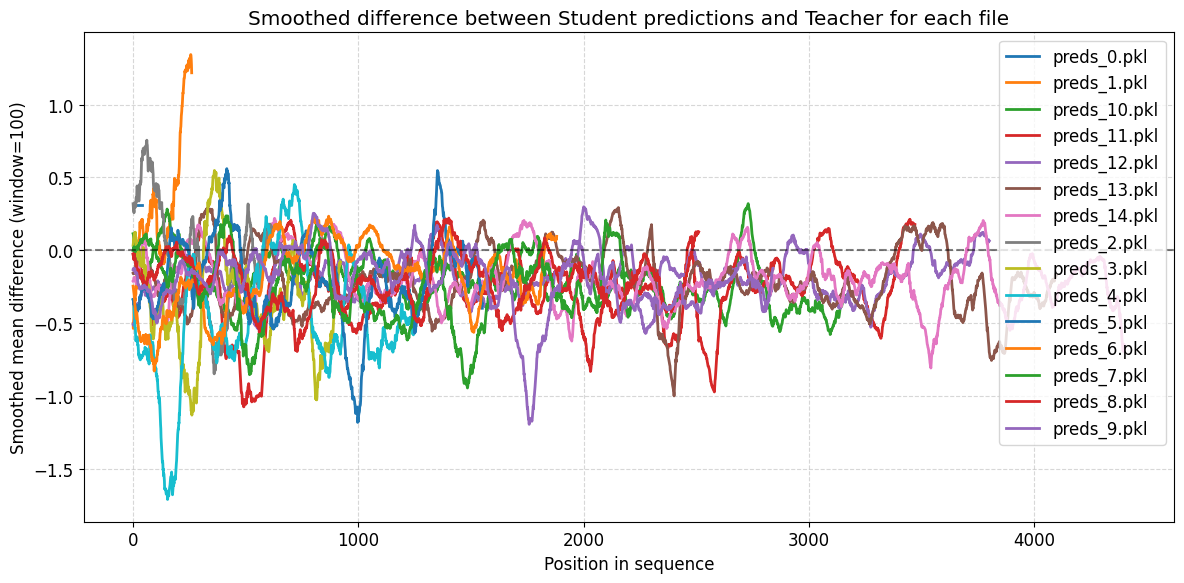

In [7]:
# --- Liste de tous les fichiers pickle ---
preds_pickle_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))
print(f"Found {len(preds_pickle_files)} pickle files.")

window_size = 100  # taille de la fenêtre de la moyenne glissante

plt.figure(figsize=(12, 6))

for path in preds_pickle_files:
    # --- Load pickle ---
    with open(path, "rb") as f:
        data = pickle.load(f)
    
    student_preds = data["student_pred_samples"]
    teacher_truth = data["teacher_true_samples"]
    
    # Flatten sequences
    student_preds_flat = [np.array(s).flatten() for s in student_preds]
    teacher_truth_flat = [np.array(t).flatten() for t in teacher_truth]
    
    # Compute difference for each sequence
    diffs = [s - t for s, t in zip(student_preds_flat, teacher_truth_flat)]
    
    # Compute mean difference across sequences in this file
    mean_diff = np.mean(np.stack(diffs), axis=0)
    
    # --- Apply moving average / rolling mean ---
    smoothed_diff = np.convolve(mean_diff, np.ones(window_size)/window_size, mode='valid')
    
    # Plot smoothed mean difference
    plt.plot(smoothed_diff, lw=2, label=os.path.basename(path))

plt.axhline(0, color='k', linestyle='--', alpha=0.5)  # zero line
plt.xlabel("Position in sequence")
plt.ylabel(f"Smoothed mean difference (window={window_size})")
plt.title("Smoothed difference between Student predictions and Teacher for each file")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()